# Càrrega de les dades

En aquesta primera secció es realitza la configuració de l'entorn de treball mitjançant el muntatge de Google Drive, s'importa la llibreria Pandas i es duu a terme la càrrega del fitxer de dades original per a la seva posterior exploració i transformació.

In [1]:
# Importem llibreries necessàries
import pandas as pd
from google.colab import drive

# Muntem la unitat de Drive
drive.mount('/content/drive')

# Definim la ruta del fitxer
file = "/content/drive/MyDrive/Màster ciència de dades/TFM/Dades LLEQuirúrgica2025_tots_grups_StaCaterina.xlsx"

# Carreguem les dades
df= pd.read_excel(file)

# Confirmem la càrrega
df.head()

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Data anàlisi,És mes corrent,Identificador de registre,NIA,Regió sanitària UP declarant (nom),UP declarant (nom),Especialitat (nom),Gran grup (nom),Grup monitorització (nom),ABS pacient (nom),...,Dies en baixa temporal,Data prevista intervenció,Data de realització de la intervenció,Dies d'espera (sense BT),Data de baixa en llista d'espera,Motiu de baixa (nom),Entrades,Sortides,Intervencions,Intervencions fora termini (sense BT)
0,2023-03-01,0,100000065164,2803533,Girona,Hospital Santa Caterina,Cirurgia plàstica,Oncologia 45 dies,Neoplàsia maligna de pell,Torroella de Montgrí,...,0,2022-04-12 00:00:00,2022-04-12 00:00:00,0,9999-09-09 00:00:00,Activitat realitzada,0,0,0,0
1,2023-06-01,0,100000064109,10976150,Girona,Hospital Santa Caterina,Cirurgia general i digestiva,Oncologia 45 dies,Neoplàsia maligna altres localitzacions,Arbúcies - Sant Hilari,...,0,2022-03-10 00:00:00,2022-03-10 00:00:00,0,9999-09-09 00:00:00,Activitat realitzada,0,0,0,0
2,2023-03-01,0,100000063092,7373066,Girona,Hospital Santa Caterina,Ginecologia,Oncologia 45 dies,Neoplàsia maligna de mama,Sils - Vidreres - Maçanet de la Selva,...,0,2022-01-18 00:00:00,2022-01-18 00:00:00,0,9999-09-09 00:00:00,Activitat realitzada,0,0,0,0
3,2022-08-01,0,100000063092,7373066,Girona,Hospital Santa Caterina,Ginecologia,Oncologia 45 dies,Neoplàsia maligna de mama,Sils - Vidreres - Maçanet de la Selva,...,0,2022-01-18 00:00:00,2022-01-18 00:00:00,0,9999-09-09 00:00:00,Activitat realitzada,0,0,0,0
4,2023-03-01,0,100000065673,6942081,Girona,Hospital Santa Caterina,Ginecologia,Oncologia 45 dies,Neoplàsia maligna de mama,Salt,...,0,2022-05-10 00:00:00,2022-05-10 00:00:00,0,9999-09-09 00:00:00,Activitat realitzada,0,0,0,0


# Anàlisi inicial de les dades

En aquest apartat es realitza una exploració inicial del conjunt de dades amb l’objectiu de comprendre’n l’estructura, identificar el tipus de variables i detectar possibles problemes de qualitat de dades.

In [2]:
# Mostrem la informació general del dataframe: nombre de files, columnes, tipus de dades i valors no nuls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196327 entries, 0 to 196326
Data columns (total 34 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   Data anàlisi                           196327 non-null  datetime64[ns]
 1   És mes corrent                         196327 non-null  int64         
 2   Identificador de registre              196327 non-null  int64         
 3   NIA                                    196327 non-null  int64         
 4   Regió sanitària UP declarant (nom)     196327 non-null  object        
 5   UP declarant (nom)                     196327 non-null  object        
 6   Especialitat (nom)                     196327 non-null  object        
 7   Gran grup (nom)                        196327 non-null  object        
 8   Grup monitorització (nom)              196327 non-null  object        
 9   ABS pacient (nom)                      196327 no

L’exploració mitjançant df.info() mostra que el conjunt de dades està format per 196.327 registres i 34 variables, proporcionant una base de dades àmplia i representativa per a l’anàlisi.

Es destaca que variables clau com NIA (identificador de pacient) i Identificador de registre (episodi) no presenten valors nuls, fet que garanteix la traçabilitat dels casos i permet construir una anàlisi fiable a nivell d’episodi.

D’altra banda, s’observa que diverses variables temporals (com les dates de baixa temporal, intervenció o baixa en llista d’espera) es troben en format object en lloc de datetime. Aquest fet requereix una transformació posterior per poder realitzar correctament càlculs temporals i anàlisi de procés.

In [3]:
# Mostrem el nombre de valors únics (diferents) que hi ha en cada columna del dataframe
df.nunique()

,0
Data anàlisi,48
És mes corrent,1
Identificador de registre,10174
NIA,7477
Regió sanitària UP declarant (nom),1
UP declarant (nom),1
Especialitat (nom),10
Gran grup (nom),3
Grup monitorització (nom),16
ABS pacient (nom),61


L’anàlisi dels valors únics confirma que el dataset té una estructura longitudinal basada en talls mensuals, on un mateix episodi pot aparèixer repetidament al llarg del temps.

S’observa que hi ha més episodis que pacients, fet coherent amb la possibilitat que un pacient entri diverses vegades en llista d’espera.

A més, es detecten variables binàries que representen estats del procés assistencial i variables temporals amb alta variabilitat, essencials per a l’anàlisi de temps i procés.

Finalment, s’identifiquen variables amb un únic valor que no aporten informació rellevant i que es podran excloure en fases posteriors.

In [4]:
# Mostra els anys diferents que apareixen a la columna "Data anàlisi"
# per comprovar els anys que estem analitzant
df["Data anàlisi"].dt.year.unique()

array([2023, 2022, 2024, 2025], dtype=int32)

In [5]:
# Estructura temporal: confirmem que tenim 12 mesos de l'any.
# Observem el nombre de registres que tenim per mes.
df["Data anàlisi"].dt.month.value_counts().sort_index()

,count
Data anàlisi,
1,14138
2,14506
3,14892
4,15188
5,15617
6,15800
7,16557
8,17054
9,17583


El dataset cobreix el període 2022-2025, permetent analitzar l’evolució de les llistes d’espera en el temps. A més, es confirma una estructura mensual completa, amb registres per a tots els mesos de l’any,

**Anàlisi de variables**

En aquest apartat es realitza una anàlisi descriptiva de les principals variables del conjunt de dades amb l’objectiu de comprendre’n la distribució, identificar el volum d’activitat segons diferents categories i detectar possibles patrons rellevants.

In [6]:
import matplotlib.pyplot as plt

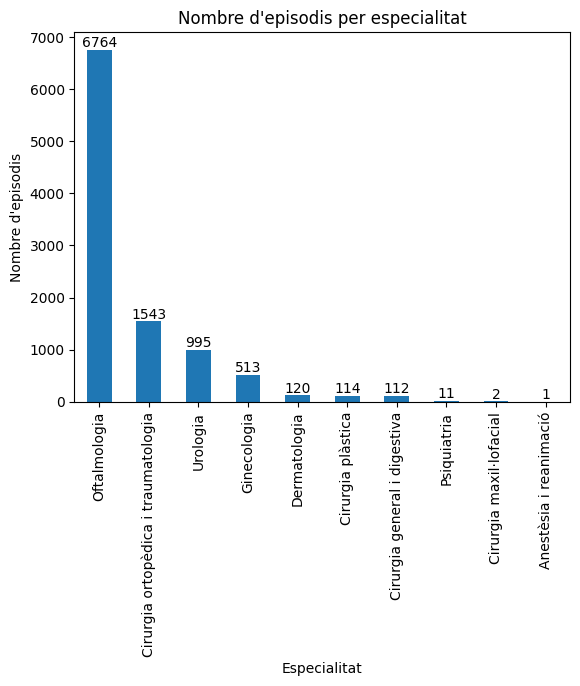

In [7]:
# Identifiquem quines especialitats tenim

# Dades
data_especialitat = df.groupby("Especialitat (nom)")["Identificador de registre"].nunique().sort_values(ascending=False)

# Gràfic
ax = data_especialitat.plot(kind="bar")

plt.title("Nombre d'episodis per especialitat")
plt.xlabel("Especialitat")
plt.ylabel("Nombre d'episodis")
plt.xticks(rotation=90)

# Etiquetes
for i, v in enumerate(data_especialitat):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

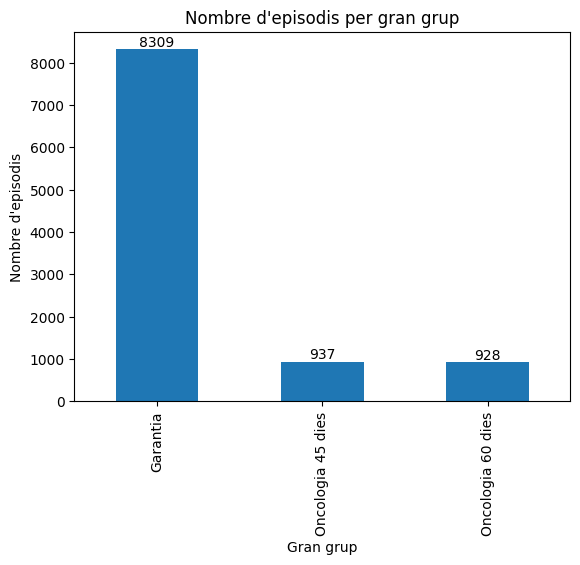

In [8]:
# Identifiquem quins grans grups tenim

# Dades
data = df.groupby("Gran grup (nom)")["Identificador de registre"].nunique()

# Gràfic
ax = data.plot(kind="bar")

plt.title("Nombre d'episodis per gran grup")
plt.xlabel("Gran grup")
plt.ylabel("Nombre d'episodis")
plt.xticks(rotation=90)

# Etiquetes
for i, v in enumerate(data):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [9]:
# Identifiquem quins procediments hi han a cada gran grup
df.groupby("Gran grup (nom)")["Grup monitorització (nom)"].agg(
    grups_unics="unique",
    n_grups="nunique"
)

,grups_unics,n_grups
Gran grup (nom),,
Garantia,"[Intervenció de cataracta, Pròtesi de maluc, P...",4
Oncologia 45 dies,"[Neoplàsia maligna de pell, Neoplàsia maligna ...",10
Oncologia 60 dies,"[Neoplàsia maligna de pròstata, Neoplàsia mali...",2


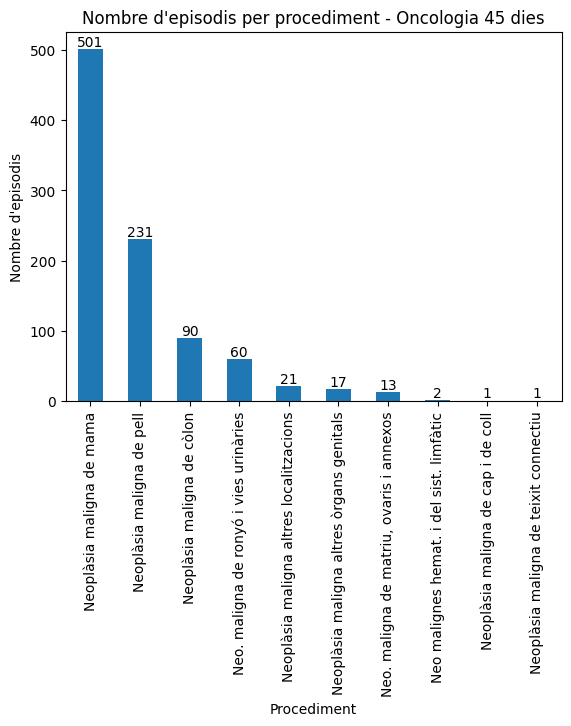

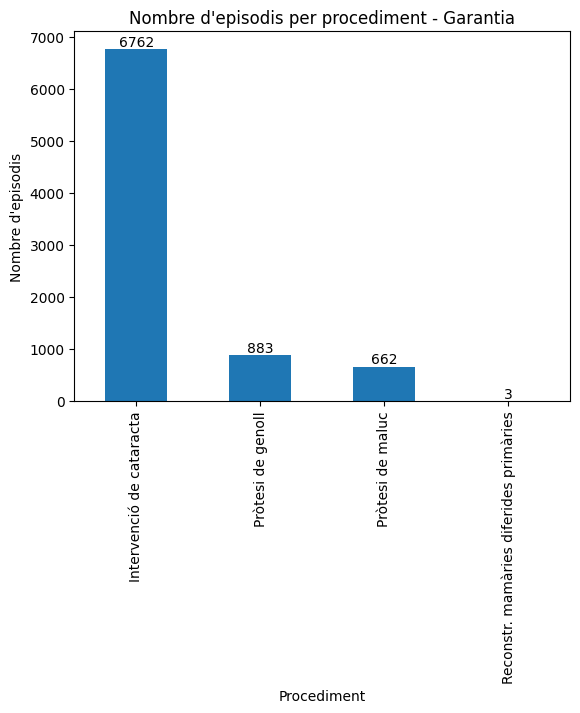

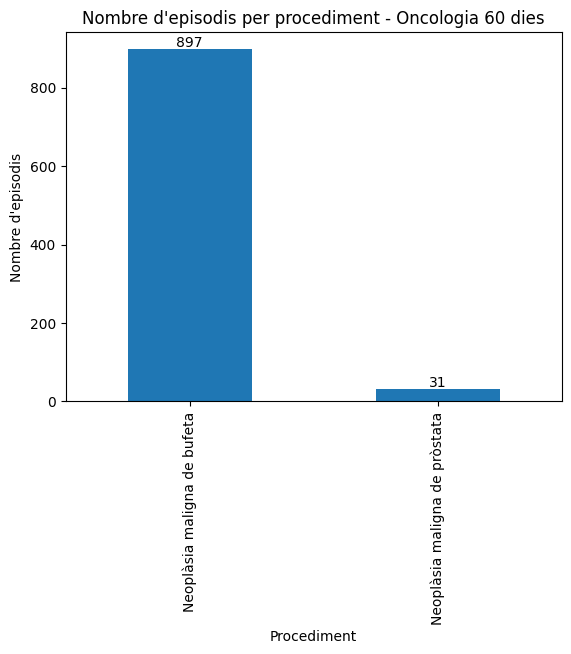

In [10]:
# Representem el volum d’episodis per procediment dins de cada gran grup, per identificar quins procediments concentren la major part de l’activitat.
# Obtenim els grups
grups = df["Gran grup (nom)"].unique()

for grup in grups:

    # Filtrar dades del grup
    df_grup = df[df["Gran grup (nom)"] == grup]

    # Comptar episodis per procediment
    data = df_grup.groupby("Grup monitorització (nom)")["Identificador de registre"].nunique().sort_values(ascending=False)

    # Gràfic
    ax = data.plot(kind="bar")

    plt.title(f"Nombre d'episodis per procediment - {grup}")
    plt.xlabel("Procediment")
    plt.ylabel("Nombre d'episodis")
    plt.xticks(rotation=90)

    # Etiquetes
    for i, v in enumerate(data):
        ax.text(i, v, str(v), ha='center', va='bottom')

    plt.show()

In [11]:
# Analitzem a quina especialitat pertany cada procediment
# Agrupem dades
df_resum = df.groupby(
    ["Grup monitorització (nom)", "Gran grup (nom)", "Especialitat (nom)"]
)["Identificador de registre"].nunique().reset_index()

# Renombrem columnes
df_resum.columns = ["procediment","gran_grup", "especialitat", "n_episodis"]

# Ordenem
df_resum = df_resum.sort_values(by="n_episodis", ascending=False)

df_resum

,procediment,gran_grup,especialitat,n_episodis
0,Intervenció de cataracta,Garantia,Oftalmologia,6762
10,Neoplàsia maligna de bufeta,Oncologia 60 dies,Urologia,888
21,Pròtesi de genoll,Garantia,Cirurgia ortopèdica i traumatologia,883
24,Pròtesi de maluc,Garantia,Cirurgia ortopèdica i traumatologia,660
14,Neoplàsia maligna de mama,Oncologia 45 dies,Ginecologia,498
16,Neoplàsia maligna de pell,Oncologia 45 dies,Dermatologia,120
15,Neoplàsia maligna de pell,Oncologia 45 dies,Cirurgia plàstica,108
12,Neoplàsia maligna de còlon,Oncologia 45 dies,Cirurgia general i digestiva,90
4,Neo. maligna de ronyó i vies urinàries,Oncologia 45 dies,Urologia,60
19,Neoplàsia maligna de pròstata,Oncologia 60 dies,Urologia,31


L’anàlisi del volum d’episodis per procediment mostra una clara concentració de l’activitat en alguns procediments. En concret, la intervenció de cataracta és el procediment amb més volum, seguida per les pròtesis de genoll i maluc dins del grup de Garantia. En canvi, la majoria de procediments oncològics presenten volums molt inferiors i més dispersos entre especialitats.

**Validació identificadors**

En aquest apartat es valida la coherència dels identificadors del dataset amb l’objectiu de comprendre correctament la seva estructura i garantir la qualitat de les dades abans de l’anàlisi.



In [12]:
print("Files totals:")
print(len(df))

print("Valors únics del camp NIA:")
print(df["NIA"].nunique())

print("Valors únics del camp identificador de registre:")
print(df["Identificador de registre"].nunique())

Files totals:
196327
Valors únics del camp NIA:
7477
Valors únics del camp identificador de registre:
10174


S’observa que el nombre total de files (196.327) és molt superior al nombre d’identificadors de registre únics (10.174). Això indica que no hi ha una única fila per episodi, sinó que cada registre pot aparèixer múltiples vegades.

Aquesta situació s’explica per l’estructura longitudinal del dataset, on cada fila representa una observació del mateix episodi en diferents moments temporals (fotografies mensuals).

Pel que fa al camp NIA, el nombre de valors únics (7.477) és inferior al nombre d’episodis, fet coherent amb la possibilitat que un mateix pacient tingui múltiples entrades en llista d’espera.

Per aquest motiu, és necessari analitzar amb més detall aquests dos camps per comprendre correctament l’estructura de les dades

In [13]:
# Mostrem el nombre de vegades que apareixen els identificadors en una fila.
df.groupby("Identificador de registre").size().sort_values(ascending=False)

,0
Identificador de registre,
100000058252,48
100000058464,48
100000063788,47
100000062630,46
100000061020,46
...,...
100000101547,1
100000101549,1
100000101550,1


Aquest anàlisi confirma que un mateix episodi pot aparèixer múltiples vegades (fins a 48 registres), corresponent als diferents talls temporals del dataset.

In [14]:
# Analitzem amb detall un dels registres.
df[df["Identificador de registre"] == 100000058252] \
.sort_values("Data anàlisi")

,Data anàlisi,És mes corrent,Identificador de registre,NIA,Regió sanitària UP declarant (nom),UP declarant (nom),Especialitat (nom),Gran grup (nom),Grup monitorització (nom),ABS pacient (nom),...,Dies en baixa temporal,Data prevista intervenció,Data de realització de la intervenció,Dies d'espera (sense BT),Data de baixa en llista d'espera,Motiu de baixa (nom),Entrades,Sortides,Intervencions,Intervencions fora termini (sense BT)
128037,2022-01-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,107,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
177563,2022-02-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,107,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
55523,2022-03-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,122,9999-09-09 00:00:00,9999-09-09 00:00:00,0,2022-03-17 00:00:00,Contraindicació mèdica temporal,0,0,0,0
177137,2022-04-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,152,9999-09-09 00:00:00,9999-09-09 00:00:00,0,2022-03-17 00:00:00,Contraindicació mèdica temporal,0,0,0,0
104430,2022-05-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
177133,2022-06-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
128040,2022-07-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
177566,2022-08-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
129033,2022-09-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0
103610,2022-10-01,0,100000058252,5382203,Girona,Hospital Santa Caterina,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de maluc,Salt,...,169,9999-09-09 00:00:00,9999-09-09 00:00:00,0,9999-09-09 00:00:00,Sense especificar,0,0,0,0


L’anàlisi detallada dels registres ha evidenciat que un mateix episodi pot aparèixer múltiples vegades en el conjunt de dades. D’una banda, es registra de manera recurrent en diferents períodes temporals, atès que el dataset té una estructura longitudinal amb observacions mensuals. D’altra banda, un mateix episodi pot aparèixer simultàniament en diferents unitats proveïdores, com a conseqüència de processos de derivació o trasllat de pacients entre centres. Això genera múltiples observacions per episodi tant en el temps com entre centres assistencials.

In [15]:
# Agrupem les dades per identificador de registre i calcula si hi ha NIA
# diferents per un mateix identificador
df.groupby("Identificador de registre")["NIA"].nunique().value_counts()

,count
NIA,
1,10174


Els resultats mostren que cada identificador de registre està associat a un únic NIA, confirmant que cada episodi correspon a un únic pacient.



Es confirma que l’identificador de registre és únic per episodi i està associat a un únic pacient (NIA). No obstant això, un mateix episodi pot aparèixer múltiples vegades en el dataset a causa de la seva estructura longitudinal. Aquesta característica s’ha de tenir en compte en l’anàlisi per evitar duplicacions i biaixos en els resultats.

A partir d’aquesta validació, es defineix l’episodi (identificador de registre) com la unitat d’anàlisi principal.

**Coherència de les dades**

Abans de realitzar la transformació de les dades, es valida la coherència temporal de les variables clau del procés assistencial.

En primer lloc, es comprova que la data de realització de la intervenció sigui sempre posterior o igual a la data d’inclusió en la llista d’espera.

In [16]:
# Comprovem que la data de realització de la intervenció és ≥ data d’inclusió
(df["Data de realització de la intervenció"] >= df["Data inclusió en llista d'espera"]).value_counts()

,count
True,196327


Els resultats mostren que aquesta condició es compleix en tots els casos, indicant que no hi ha inconsistències temporals en aquest aspecte.

A continuació, s’analitza si existeixen casos en què la data d’inclusió en llista d’espera coincideix amb la data de realització de la intervenció.

In [17]:
# Casos amb mateixa data d’entrada i intervenció
(df["Data de realització de la intervenció"] == df["Data inclusió en llista d'espera"]).value_counts()

,count
False,195996
True,331


Aqui podem veure com hi ha 331 casos on la data que s'inclou el pacient en llista d'espera coincideix amb la data de ralització de la intervenció.

# Transformació de les dades

En primer lloc, es transformen les variables temporals que en el dataset original es troben en format object a format datetime.

In [18]:
# Convertim les dates a format datetime
cols_dates = [
    "Data inici baixa temporal",
    "Data fi baixa temporal",
    "Data prevista intervenció",
    "Data de realització de la intervenció",
    "Data de baixa en llista d'espera"
]

for col in cols_dates:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

A continuació és realitza la transformació del dataset original amb l’objectiu d’adaptar-lo a diferents tipus d’anàlisi. Donada la naturalesa longitudinal de les dades, es construeixen dues estructures complementàries:

*   Una taula a nivell d’episodi (df_episodi), amb una única fila per cada entrada en llista d’espera, orientada a l’anàlisi descriptiva.
*   Una taula en format event log (df_event_log), que recull la seqüència temporal d’esdeveniments de cada episodi, orientada a l’anàlisi de procés (process mining).

Aquesta doble estructura permet combinar una visió agregada i una visió temporal del procés assistencial.

En aquesta fase es construeixen les estructures de dades necessàries, mentre que l’anàlisi descriptiva i de procés es desenvoluparà en apartats posteriors utilitzant aquestes taules.

**Creació de la taula d’episodis**

La taula d’episodis es construeix agregant la informació del dataset original per identificador de registre, obtenint una única fila per episodi i recollint les principals variables clíniques i temporals

In [19]:
# Creem una taula d'episodis
df_episodi = df.sort_values("Data anàlisi").groupby("Identificador de registre").agg({
    "NIA": "first",
    "Sexe (codi)": "first",
    "Edat (LES)": "first",
    "ABS pacient (nom)": "first",
    "Especialitat (nom)": "first",
    "Gran grup (nom)": "first",
    "Grup monitorització (nom)": "first",
    "Data inclusió en llista d'espera": "first",
    "Data inici baixa temporal": "min",
    "Data fi baixa temporal": "max",
    "Data de realització de la intervenció": "max",
    "Data de baixa en llista d'espera": "max",
    "Motiu de baixa (nom)": "last",
}).reset_index()

In [20]:
# Renombrem les columnes
df_episodi.columns = [
    "id_episodi",
    "NIA",
    "sexe",
    "edat",
    "ABS",
    "especialitat",
    "grup_intervencio",
    "procediment",
    "data_entrada",
    "data_inici_baixa_temporal",
    "data_fi_baixa_temporal",
    "data_intervencio",
    "data_baixa",
    "Motiu de baixa"
]

Per tal d’interpretar adequadament els temps d’espera, es defineixen els terminis de garantia associats a cada grup d’intervenció, els quals s’utilitzaran posteriorment per avaluar el seu compliment.

Els terminis de garantia associats a cada grup de procediment son els següents:
- Garantia (4 procediments): 180 dies.
- Oncologia 45 dies (20 procediments): 45 dies.
- Oncologia 60 dies (2 procediments): 60 dies.


In [21]:
# Creem una variable de termini
def assignar_termini(grup):
    if grup == "Garantia":
        return 180
    elif grup == "Oncologia 45 dies":
        return 45
    elif grup == "Oncologia 60 dies":
        return 60
    else:
        return None

df_episodi["termini_max"] = df_episodi["grup_intervencio"].apply(assignar_termini)

In [22]:
!pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 MB 23.7 MB/s eta 0:00:00


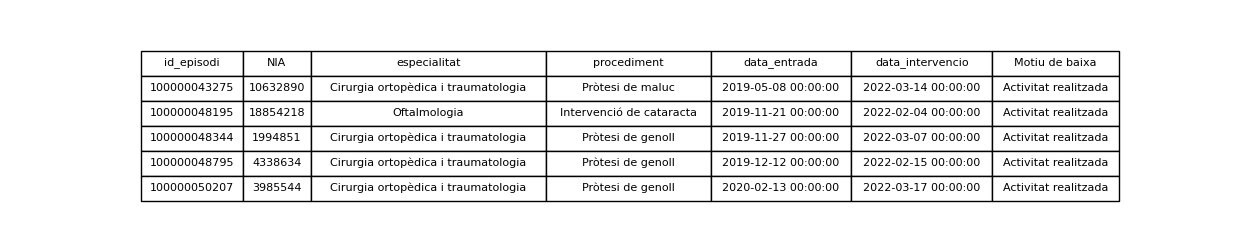

In [23]:
import matplotlib.pyplot as plt

df_episodi_visual = df_episodi[[
    "id_episodi",
    "NIA",
    "especialitat",
    "procediment",
    "data_entrada",
    "data_intervencio",
    "Motiu de baixa"
]].head()

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')

table = ax.table(
    cellText=df_episodi_visual.values,
    colLabels=df_episodi_visual.columns,
    cellLoc='center',
    loc='center'
)

# Ajustar text
table.auto_set_font_size(False)
table.set_fontsize(8)

# Ajustar escala
table.scale(1.2, 1.5)

# Ajustar amplada columnes
table.auto_set_column_width(
    col=list(range(len(df_episodi_visual.columns)))
)

plt.savefig("taula_episodis.png", bbox_inches='tight', dpi=300)

plt.show()

**Creació de l’event log**

A partir de la taula d’episodis, es construeix un event log que representa la seqüència temporal del procés assistencial, incloent esdeveniments com l’entrada en llista, l’inici i fi de baixa temporal, la intervenció i la baixa.

In [24]:
# Creem una llista d'events
eventos = []

# Construim els events
for _, row in df_episodi.iterrows():

    id_ep = row["id_episodi"]

    base_info = {
        "id_episodi": id_ep,
        "NIA": row["NIA"],
        "sexe": row["sexe"],
        "edat": row["edat"],
        "especialitat": row["especialitat"],
        "grup_intervencio": row["grup_intervencio"],
        "procediment": row["procediment"]
    }

    # 1. Entrada
    if pd.notnull(row["data_entrada"]):
        eventos.append({
            **base_info,
            "data_event": row["data_entrada"],
            "event": "entrada"
        })

    # 2. Inici baixa
    if pd.notnull(row["data_inici_baixa_temporal"]):
        eventos.append({
            **base_info,
            "data_event": row["data_inici_baixa_temporal"],
            "event": "inici_baixa_temporal"
        })

    # 3. Fi baixa
    if pd.notnull(row["data_fi_baixa_temporal"]):
        eventos.append({
            **base_info,
            "data_event": row["data_fi_baixa_temporal"],
            "event": "fi_baixa_temporal"
        })

    # 4. Intervenció
    if pd.notnull(row["data_intervencio"]):
        eventos.append({
            **base_info,
            "data_event": row["data_intervencio"],
            "event": "intervencio"
        })

    # 5. Baixa
    if pd.notnull(row["data_baixa"]):
      eventos.append({
          **base_info,
          "data_event": row["data_baixa"],
          "event": "sortida",
          "motiu_baixa": row["Motiu de baixa"]
    })

In [25]:
# Creem el dataframe
df_event_log = pd.DataFrame(eventos)

In [26]:
# Reordemen columnes
df_event_log = df_event_log[[
    "id_episodi",
    "event",
    "data_event",

    # variables de context
    "NIA",
    "sexe",
    "edat",
    "especialitat",
    "grup_intervencio",
    "procediment",

    # opcional
    "motiu_baixa"
]]

# Ordenem
df_event_log = df_event_log.sort_values(["id_episodi", "data_event"])

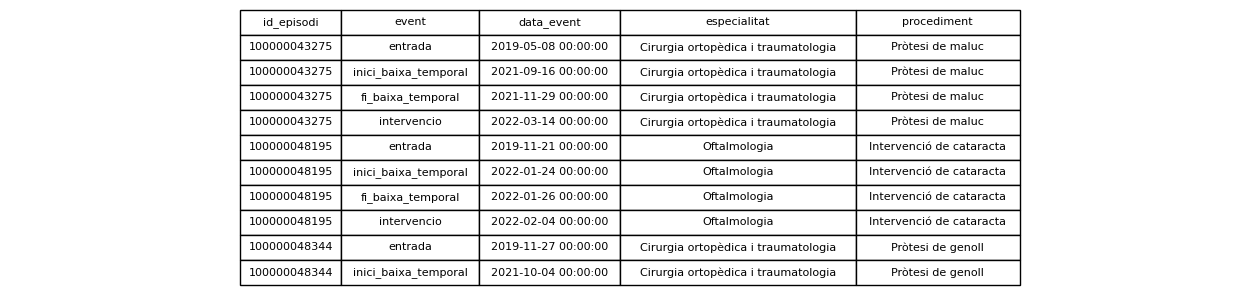

In [27]:
df_event_visual = df_event_log[[
    "id_episodi",
    "event",
    "data_event",
    "especialitat",
    "procediment"
]].head(10)

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')

table = ax.table(
    cellText=df_event_visual.values,
    colLabels=df_event_visual.columns,
    cellLoc='center',
    loc='center'
)

# Ajustar text
table.auto_set_font_size(False)
table.set_fontsize(8)

# Ajustar escala
table.scale(1.2, 1.5)

# Ajustar amplada columnes
table.auto_set_column_width(
    col=list(range(len(df_event_visual.columns)))
)

plt.savefig("taula_episodis.png", bbox_inches='tight', dpi=300)

plt.show()

# Anàlisi descriptiva

**Càlcul del temps d’espera i compliment**

Es calcula el temps total d’espera per a cada episodi com la diferència entre la data d’intervenció i la data d’entrada en llista d’espera. A partir d’aquesta variable, es defineix un indicador de compliment que compara el temps real d’espera amb el termini màxim establert segons el grup d’intervenció.

Els episodis no resolts (sense intervenció) s’exclouen del càlcul del compliment per evitar biaixos en els resultats.

In [28]:
# Calculem el temps total en llista d'espera
df_episodi["temps_total_espera"] = (
    df_episodi["data_intervencio"] - df_episodi["data_entrada"]
).dt.days

In [29]:
# Compliment
df_episodi["compliment"] = df_episodi["temps_total_espera"] <= df_episodi["termini_max"]

df_episodi.loc[df_episodi["temps_total_espera"].isna(), "compliment"] = None


/tmp/ipykernel_1175/1069914526.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_episodi.loc[df_episodi["temps_total_espera"].isna(), "compliment"] = None


**Volum d'intervencions**

A continuació, s’analitza el volum d’episodis resolts (intervinguts) per grup d’intervenció.

In [30]:
df_episodi["any_entrada"] = df_episodi["data_entrada"].dt.year
df_episodi["any_intervencio"] = df_episodi["data_intervencio"].dt.year

In [31]:
# Operacions realitzades
df_operats = df_episodi[df_episodi["data_intervencio"].notna()]

# Agrupar i comptar
taula_operacions = (
    df_operats
    .groupby("grup_intervencio")["id_episodi"]
    .count()
    .reset_index()
    .rename(columns={
        "grup_intervencio": "Grup intervenció",
        "id_episodi": "Nombre episodis"
    })
    .sort_values(by="Nombre episodis", ascending=False)
)

# Mostrar taula
display(taula_operacions.head(10))

,Grup intervenció,Nombre episodis
0,Garantia,5651
1,Oncologia 45 dies,849
2,Oncologia 60 dies,779


El volum d’activitat es concentra principalment en el grup de Garantia, amb un nombre molt superior d’intervencions respecte als grups oncològics. Això indica que, tot i tenir un menor nivell de compliment, aquest grup representa la major càrrega assistencial del sistema.

Es detecta una relació inversa entre el volum d’activitat i el grau de compliment dels terminis, amb pitjors resultats en els grups amb major càrrega assistencial.

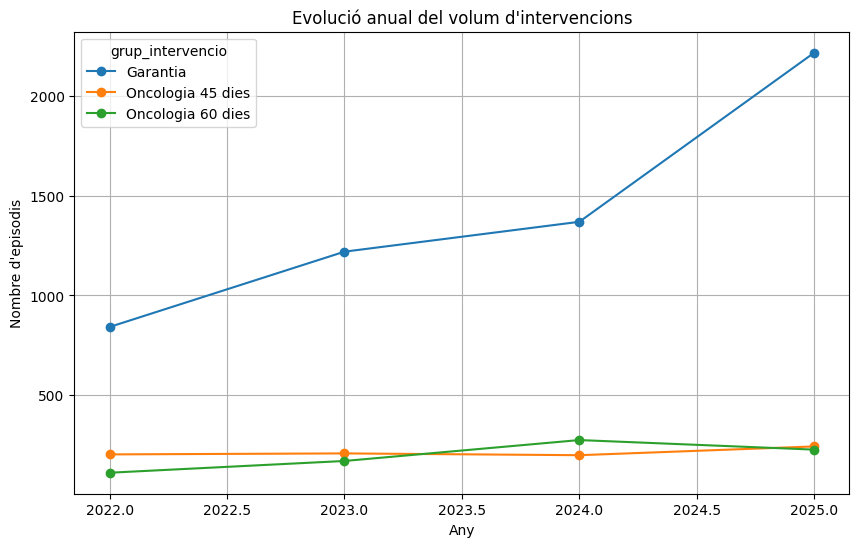

In [32]:
# Evolució anual del lvolum
df_graf = (
    df_operats
    .groupby(["any_intervencio", "grup_intervencio"])["id_episodi"]
    .count()
    .reset_index()
)

# Convertir format per pintar
pivot_df = df_graf.pivot(
    index="any_intervencio",
    columns="grup_intervencio",
    values="id_episodi"
)

# Gràfica
pivot_df.plot(marker="o", figsize=(10,6))

plt.title("Evolució anual del volum d'intervencions")
plt.xlabel("Any")
plt.ylabel("Nombre d'episodis")
plt.grid(True)

plt.show()

**Temps d'espera**



In [33]:
df_episodi.groupby("grup_intervencio")["temps_total_espera"].describe()

,count,mean,std,min,25%,50%,75%,max
grup_intervencio,,,,,,,,
Garantia,5651.0,184.481862,95.289029,0.0,133.0,180.0,228.0,1041.0
Oncologia 45 dies,849.0,17.228504,19.237336,0.0,8.0,11.0,19.0,231.0
Oncologia 60 dies,779.0,43.412067,18.696835,0.0,32.0,41.0,53.0,160.0


L’anàlisi del temps d’espera mostra diferències molt significatives entre els grups d’intervenció.

El grup de Garantia presenta un temps d’espera mitjà elevat (184 dies), amb una mediana de 180 dies, situant-se pràcticament al límit del termini establert (180 dies). A més, mostra una elevada dispersió (desviació estàndard de 95 dies), indicant una gran variabilitat en els temps d’espera.

En canvi, els grups oncològics presenten temps d’espera considerablement inferiors:

*   Oncologia 45 dies: mediana de 11 dies
*   Oncologia 60 dies: mediana de 41 dies

Aquests valors indiquen un millor ajust als terminis establerts, especialment en el grup de major prioritat (45 dies).

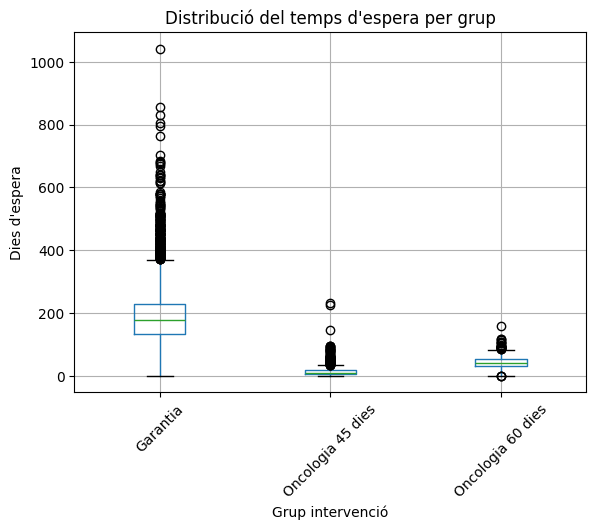

In [34]:
# Ho representem gràficament: boxplot
df_episodi.boxplot(
    column="temps_total_espera",
    by="grup_intervencio"
)

plt.title("Distribució del temps d'espera per grup")
plt.suptitle("")  # treu títol automàtic
plt.xlabel("Grup intervenció")
plt.ylabel("Dies d'espera")
plt.xticks(rotation=45)

plt.show()

El primer gràfic mostra la presència de nombrosos valors extrems, especialment en el grup de Garantia, amb casos que superen àmpliament els 400 dies i arriben fins a més de 1.000 dies d’espera.

Aquests outliers indiquen situacions excepcionals o possibles incidències en el procés assistencial, i evidencien l’existència de pacients amb demores molt elevades.

En els grups oncològics també es detecten alguns valors extrems, però amb una magnitud considerablement inferior.

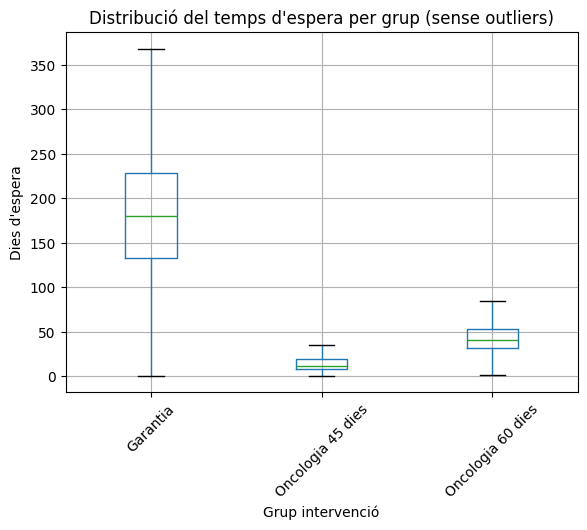

In [35]:
# Mostrem el gràfic sense outliers

df_episodi.boxplot(
    column="temps_total_espera",
    by="grup_intervencio",
    showfliers=False
)

plt.title("Distribució del temps d'espera per grup (sense outliers)")
plt.suptitle("")
plt.xlabel("Grup intervenció")
plt.ylabel("Dies d'espera")
plt.xticks(rotation=45)

plt.show()

En eliminar els valors extrems, es visualitza amb més claredat la distribució principal dels temps d’espera.

S’observa que:

- El grup de Garantia presenta una distribució molt més dispersa, amb un rang ampli de valors.
- Oncologia 45 dies mostra una distribució molt concentrada, indicant un procés més controlat i homogeni.
- Oncologia 60 dies presenta una dispersió moderada, situant-se entre els dos casos anteriors.

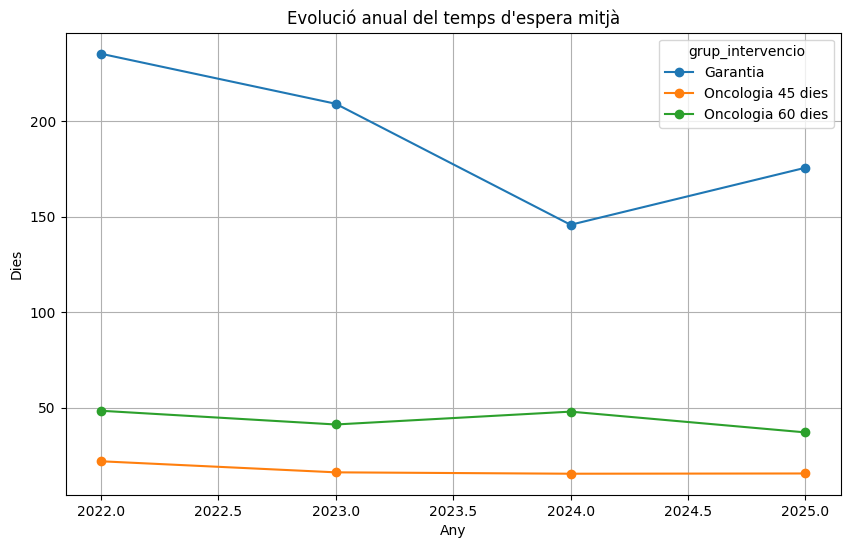

In [36]:
# Evolució anual del temps d'espera mitjà

df_temps_any = (
    df_operats
    .groupby(["any_intervencio", "grup_intervencio"])["temps_total_espera"]
    .mean()
    .reset_index()
)

# Convertim format
pivot_temps = df_temps_any.pivot(
    index="any_intervencio",
    columns="grup_intervencio",
    values="temps_total_espera"
)

# Gràfic
pivot_temps.plot(marker="o", figsize=(10,6))

plt.title("Evolució anual del temps d'espera mitjà")
plt.xlabel("Any")
plt.ylabel("Dies")
plt.grid(True)

plt.show()

In [98]:
df_episodi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_episodi                 10174 non-null  int64         
 1   NIA                        10174 non-null  int64         
 2   sexe                       10174 non-null  int64         
 3   edat                       10174 non-null  int64         
 4   ABS                        10174 non-null  object        
 5   especialitat               10174 non-null  object        
 6   grup_intervencio           10174 non-null  object        
 7   procediment                10174 non-null  object        
 8   data_entrada               10174 non-null  datetime64[ns]
 9   data_inici_baixa_temporal  790 non-null    datetime64[ns]
 10  data_fi_baixa_temporal     745 non-null    datetime64[ns]
 11  data_intervencio           7279 non-null   datetime64[ns]
 12  data

**Pacients fora de termini**

In [37]:
# % compliment
resultat = df_episodi.groupby("grup_intervencio")["compliment"].mean() * 100
print(resultat.map(lambda x: f"{x:.2f}%"))

grup_intervencio
Garantia             50.43%
Oncologia 45 dies    92.93%
Oncologia 60 dies    85.24%
Name: compliment, dtype: object


Els resultats mostren diferències significatives en el grau de compliment dels terminis entre grups d’intervenció.

El grup de Oncologia 45 dies presenta un alt nivell de compliment (92,93%), fet coherent amb la seva elevada prioritat clínica. De manera similar, Oncologia 60 dies també mostra un bon nivell de compliment (85,24%).

En canvi, el grup de Garantia presenta un nivell de compliment notablement inferior (50,43%), indicant que aproximadament la meitat dels episodis es resolen fora del termini establert. Aquest resultat suggereix la possible existència de colls d’ampolla o limitacions de capacitat en aquest tipus de procediments.

In [38]:
# % pacients fora de termini
(1 - df_episodi.groupby("grup_intervencio")["compliment"].mean()) * 100

,compliment
grup_intervencio,
Garantia,49.566448
Oncologia 45 dies,7.067138
Oncologia 60 dies,14.762516


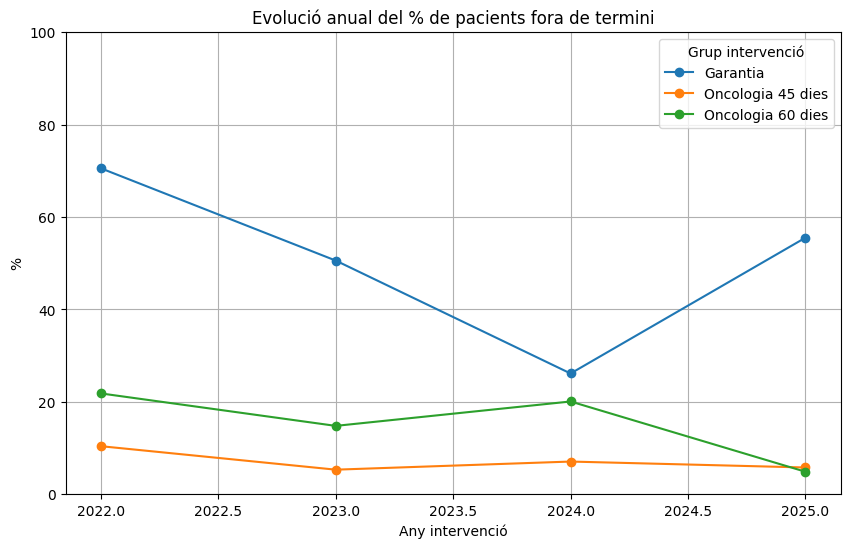

In [39]:
# Tendència per any pacients fora termini
df_graf = (
    df_episodi
    .assign(no_compliment = df_episodi["compliment"] == False)
    .groupby(["any_intervencio", "grup_intervencio"])["no_compliment"]
    .mean()
    .mul(100)
    .reset_index()
)

# Format gràfica
pivot_df = df_graf.pivot(
    index="any_intervencio",
    columns="grup_intervencio",
    values="no_compliment"
)

# Gràfic
pivot_df.plot(
    marker="o",
    figsize=(10,6)
)

plt.title("Evolució anual del % de pacients fora de termini")
plt.xlabel("Any intervenció")
plt.ylabel("%")

plt.ylim(0, 100)
plt.grid(True)

plt.legend(title="Grup intervenció")

plt.show()

**Conclusió anàlisi descriptiva:**

L’anàlisi descriptiva del dataset permet identificar diferències rellevants entre els grups d’intervenció tant en volum com en temps d’espera i grau de compliment dels terminis establerts.

Els resultats mostren que el grup de Garantia concentra la major part de l’activitat assistencial, però també presenta una elevada variabilitat en els temps d’espera i un baix nivell de compliment. En canvi, els grups oncològics, tot i tenir menor volum, mostren una gestió més eficient del temps, amb distribucions més homogènies i un major grau d’ajust als terminis clínics.

A més, la presència de valors extrems en els temps d’espera, especialment en el grup de Garantia, suggereix l’existència de possibles colls d’ampolla o ineficiències en el procés assistencial.

Aquestes diferències posen de manifest la necessitat d’analitzar amb més profunditat el flux dels pacients dins del sistema, fet que justifica l’aplicació de tècniques de process mining en la següent secció.

# Anàlisi Process Mining

En aquesta secció s’apliquen tècniques de process mining amb l’objectiu de comprendre el flux dels pacients dins la llista d’espera quirúrgica, identificar els principals camins del procés i detectar possibles colls d’ampolla en termes de temps.

In [40]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.2 MB/s eta 0:00:00


**Preparació de les dades**

Abans de l’anàlisi, es prepara el dataset en format event log assegurant l’ordenació temporal dels esdeveniments i la correcta definició dels identificadors de cas, activitats i timestamps.

In [41]:
import pm4py

# Ordenem cronològicament els esdeveniments dins de cada episodi
df_event_log = df_event_log.sort_values(['id_episodi', 'data_event'])

# Convertim identificador a format string
df_event_log['id_episodi'] = df_event_log['id_episodi'].astype(str)

# Formategem el dataframe com a event log
df_event_log = pm4py.format_dataframe(
    df_event_log,
    case_id='id_episodi',
    activity_key='event',
    timestamp_key='data_event'
)

Aquesta transformació és necessària perquè les eines de process mining puguin interpretar correctament la seqüència d’esdeveniments i reconstruir el procés assistencial.

**Anàlisi inicial (events, freqüències)**

1. Freqüència d'esdeveniments

In [42]:
df_event_log["event"].value_counts()

,count
event,
entrada,10174
intervencio,7279
sortida,2373
inici_baixa_temporal,790
fi_baixa_temporal,745


2. Nombre d'episodis (casos)

In [43]:
df_event_log["id_episodi"].nunique()

10174

3. Nombre mitjà d’esdeveniments per episodi

In [44]:
df_event_log.groupby("id_episodi").size().mean()

np.float64(2.0995675250638883)

4. Anàlisi de variants del procés

In [45]:
variants = pm4py.get_variants(df_event_log)

# Nombre total de variants
print("Nombre de variants diferents:")
print(len(variants))

# Top variants més freqüents
variants_count = []

for variant, casos in variants.items():
    variants_count.append({
        "variant": " -> ".join(variant),
        "casos": casos
    })

df_variants = pd.DataFrame(variants_count)

df_variants = df_variants.sort_values(
    by="casos",
    ascending=False
)

df_variants.head(15)

Nombre de variants diferents:
12


,variant,casos
1,entrada -> intervencio,6772
3,entrada -> sortida,1704
5,entrada,908
4,entrada -> inici_baixa_temporal -> sortida -> ...,404
2,entrada -> inici_baixa_temporal -> fi_baixa_te...,196
0,entrada -> inici_baixa_temporal -> fi_baixa_te...,97
7,entrada -> inici_baixa_temporal -> sortida,39
6,entrada -> inici_baixa_temporal -> fi_baixa_te...,24
9,entrada -> inici_baixa_temporal -> sortida -> ...,14
8,entrada -> sortida -> inici_baixa_temporal -> ...,10


**Heuristic Miner**

Per obtenir una representació clara del flux del procés, s’utilitza l’algorisme Heuristic Miner. Aquest algorisme permet identificar les relacions més freqüents entre activitats, reduint l’impacte de comportaments poc habituals i facilitant la interpretació del procés.

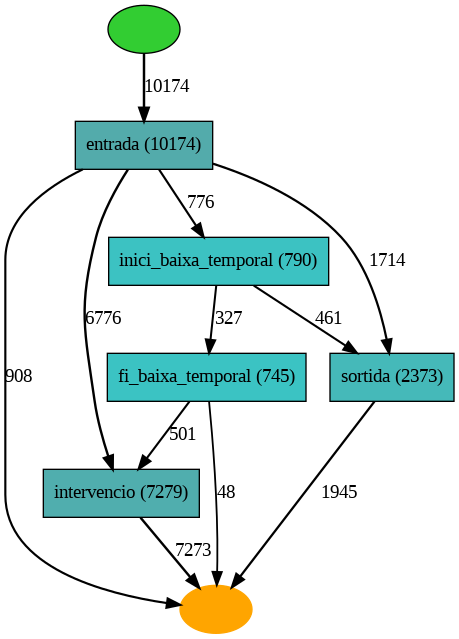

In [46]:
# Apliquem l'algorisme
mapa = pm4py.discover_heuristics_net(
    df_event_log,
    case_id_key='id_episodi',
    activity_key='event',
    timestamp_key='data_event'
)

# Vizualitzem el resultat
pm4py.view_heuristics_net(mapa)

El model obtingut mostra l’estructura general del procés assistencial de la llista d’espera quirúrgica.

El procés s’inicia amb l’esdeveniment entrada en llista d’espera, present en tots els episodis.

A partir d’aquest punt, es poden identificar tres camins principals:

- entrada - intervenció (flux majoritari)
- entrada - baixa temporal - intervenció
- entrada - sortida

També podem observar com un nombre significatiu de pacients (1714 casos) surt de la llista sense intervenció. En apartats posteriors s'analitzarà els motius de sortida d'aquests casos.

A més, veiem com 908 pacients passen directament de l'entrada al final del procés sense cap esdeveniment posterior registrat. Aquests casos corresponen probablement a episodis encara oberts en el moment de l’extracció de dades, és a dir, pacients que continuen en llista d’espera i que encara no han estat intervinguts ni han sortit del sistema.

Tot i que aquest model permet comprendre l’estructura del procés, no proporciona informació sobre els temps entre activitats. Per aquest motiu, en el següent apartat es realitza una anàlisi de rendiment per identificar possibles colls d’ampolla.

**Anàlisi del rendiment (DFG)**

Per analitzar els temps entre activitats, es construeix un Directly-Follows Graph (DFG) de rendiment, que permet visualitzar el temps mitjà entre cada parella d’esdeveniments.

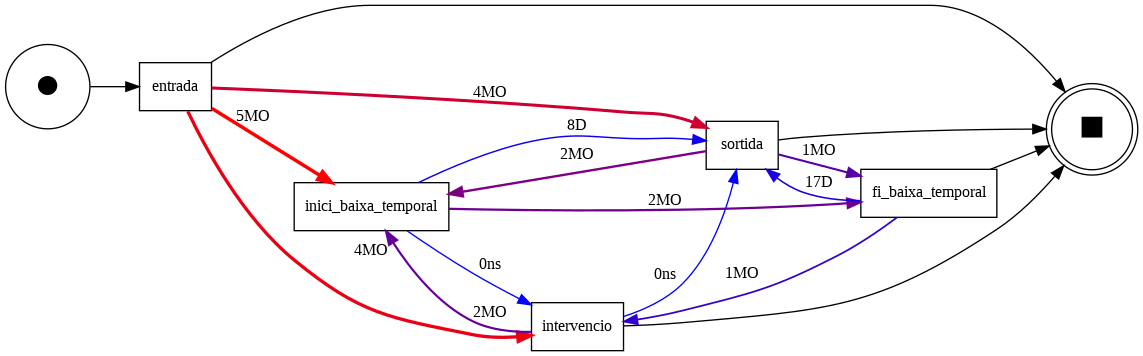

In [47]:
performance_map = pm4py.discover_performance_dfg(df_event_log,
                                                 case_id_key='id_episodi',
                                                 activity_key='event',
                                                 timestamp_key='data_event')

pm4py.view_performance_dfg(performance_map[0], performance_map[1], performance_map[2])

Aquest anàlisi permet identificar clarament diferències en els temps entre les diferents fases del procés.

S'observa que els temps més elevats es concentren en les fases inicials
- entrada → inici baixa temporal (~5 mesos)
- entrada → intervenció (~5 mesos)
- entrada → sortida (~4 mesos)

En canvi, les fases finals del procés presenten temps reduïts:
- fi baixa temporal → intervenció (~1 mes)
- intervenció → sortida (~0 dies): te sentit ja que quan es realitza l'intervenció el pacient ja surt de la llista d'espera.

Tot i així, s’observen connexions que no són coherents des del punt de vista clínic. En particular, es detecten trajectòries en què, després de l’esdeveniment “sortida”, apareixen esdeveniments posteriors com “inici de baixa temporal”. També s’identifiquen casos en què, després de la intervenció, es registren esdeveniments de baixa temporal.

Aquest comportament és inconsistent, ja que tant la intervenció com la sortida de la llista d’espera haurien de representar el final del procés per a aquell episodi.

Anàlisi de casos anòmals:

Per analitzar les inconsistències detectades anteriorment, es quantifica el nombre d’episodis que presenten aquestes seqüències no esperades:
- sortida → inici de baixa temporal
- intervenció → inici de baixa temporal

In [48]:
from pm4py.algo.filtering.log.paths import paths_filter

# Definim les seqüències anòmales
seq_anomales = [
    ('sortida', 'inici_baixa_temporal'),
    ('intervencio', 'inici_baixa_temporal')
]

# Comptem casos per cada seqüència
for seq in seq_anomales:
    casos = paths_filter.apply(df_event_log, [seq])
    print(f"Seqüència {seq}: {len(casos)} casos")

Seqüència ('sortida', 'inici_baixa_temporal'): 10 casos
Seqüència ('intervencio', 'inici_baixa_temporal'): 4 casos


Els resultats mostren que aquests casos són molt poc freqüents (10 i 4 episodis), cosa que indica que es tracta de situacions puntuals i no d’un patró estructural del procés.

A continuació inspeccionem aquests 14 casos.

In [49]:
# Definim una funció per obtenir es casos segons la seqüència que vulguem analitzar.
def obtenir_casos_anomals(df, event1, event2):
    df_sorted = df.sort_values(['id_episodi', 'data_event'])
    df_sorted['next_event'] = df_sorted.groupby('id_episodi')['event'].shift(-1)

    ids = df_sorted[
        (df_sorted['event'] == event1) &
        (df_sorted['next_event'] == event2)
    ]['id_episodi'].unique()

    return df[df['id_episodi'].isin(ids)].sort_values(['id_episodi', 'data_event'])

In [50]:
# Cassos sortida - inici baixa temporal
taula_sortida_inici_baixa = obtenir_casos_anomals(
    df_event_log,
    'sortida',
    'inici_baixa_temporal'
)

taula_sortida_inici_baixa

,id_episodi,event,data_event,NIA,sexe,edat,especialitat,grup_intervencio,procediment,motiu_baixa,case:concept:name,concept:name,time:timestamp,@@index,@@case_index,start_timestamp
3040,100000064892,entrada,2022-03-28 00:00:00+00:00,3289899,0,86,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000064892,entrada,2022-03-28 00:00:00+00:00,3040,1322,2022-03-28 00:00:00+00:00
3041,100000064892,sortida,2022-11-22 00:00:00+00:00,3289899,0,86,Oftalmologia,Garantia,Intervenció de cataracta,Trasllat a un altre centre,100000064892,sortida,2022-11-22 00:00:00+00:00,3041,1322,2022-11-22 00:00:00+00:00
3042,100000064892,inici_baixa_temporal,2023-06-27 00:00:00+00:00,3289899,0,86,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000064892,inici_baixa_temporal,2023-06-27 00:00:00+00:00,3042,1322,2023-06-27 00:00:00+00:00
3043,100000064892,fi_baixa_temporal,2023-07-24 00:00:00+00:00,3289899,0,86,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000064892,fi_baixa_temporal,2023-07-24 00:00:00+00:00,3043,1322,2023-07-24 00:00:00+00:00
4835,100000068455,entrada,2022-09-20 00:00:00+00:00,5859816,0,85,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000068455,entrada,2022-09-20 00:00:00+00:00,4835,2156,2022-09-20 00:00:00+00:00
4836,100000068455,sortida,2023-03-23 00:00:00+00:00,5859816,0,85,Oftalmologia,Garantia,Intervenció de cataracta,Trasllat a un altre centre,100000068455,sortida,2023-03-23 00:00:00+00:00,4836,2156,2023-03-23 00:00:00+00:00
4837,100000068455,inici_baixa_temporal,2023-12-14 00:00:00+00:00,5859816,0,85,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000068455,inici_baixa_temporal,2023-12-14 00:00:00+00:00,4837,2156,2023-12-14 00:00:00+00:00
4838,100000068455,fi_baixa_temporal,2024-01-13 00:00:00+00:00,5859816,0,85,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000068455,fi_baixa_temporal,2024-01-13 00:00:00+00:00,4838,2156,2024-01-13 00:00:00+00:00
7529,100000074725,entrada,2023-06-07 00:00:00+00:00,706359,0,73,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de genoll,NaN,100000074725,entrada,2023-06-07 00:00:00+00:00,7529,3387,2023-06-07 00:00:00+00:00
7530,100000074725,sortida,2023-10-05 00:00:00+00:00,706359,0,73,Cirurgia ortopèdica i traumatologia,Garantia,Pròtesi de genoll,Trasllat a un altre centre,100000074725,sortida,2023-10-05 00:00:00+00:00,7530,3387,2023-10-05 00:00:00+00:00


S'observa que els casos identificats com a anòmals corresponen principalment a pacients amb trasllat a un altre centre.



In [51]:
# Casos intervenció - inici baixa temporal
taula_intervencio_inici_baixa = obtenir_casos_anomals(
    df_event_log,
    'intervencio',
    'inici_baixa_temporal'
)

taula_intervencio_inici_baixa

,id_episodi,event,data_event,NIA,sexe,edat,especialitat,grup_intervencio,procediment,motiu_baixa,case:concept:name,concept:name,time:timestamp,@@index,@@case_index,start_timestamp
10213,100000079807,entrada,2023-12-22 00:00:00+00:00,3981708,0,64,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000079807,entrada,2023-12-22 00:00:00+00:00,10213,4586,2023-12-22 00:00:00+00:00
10214,100000079807,intervencio,2024-04-09 00:00:00+00:00,3981708,0,64,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000079807,intervencio,2024-04-09 00:00:00+00:00,10214,4586,2024-04-09 00:00:00+00:00
10215,100000079807,inici_baixa_temporal,2024-07-08 00:00:00+00:00,3981708,0,64,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000079807,inici_baixa_temporal,2024-07-08 00:00:00+00:00,10215,4586,2024-07-08 00:00:00+00:00
10216,100000079807,sortida,2024-07-08 00:00:00+00:00,3981708,0,64,Oftalmologia,Garantia,Intervenció de cataracta,Activitat realitzada,100000079807,sortida,2024-07-08 00:00:00+00:00,10216,4586,2024-07-08 00:00:00+00:00
10962,100000081484,entrada,2024-02-23 00:00:00+00:00,6780421,1,77,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000081484,entrada,2024-02-23 00:00:00+00:00,10962,4897,2024-02-23 00:00:00+00:00
10963,100000081484,intervencio,2024-05-20 00:00:00+00:00,6780421,1,77,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000081484,intervencio,2024-05-20 00:00:00+00:00,10963,4897,2024-05-20 00:00:00+00:00
10964,100000081484,inici_baixa_temporal,2024-07-20 00:00:00+00:00,6780421,1,77,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000081484,inici_baixa_temporal,2024-07-20 00:00:00+00:00,10964,4897,2024-07-20 00:00:00+00:00
10965,100000081484,sortida,2024-07-20 00:00:00+00:00,6780421,1,77,Oftalmologia,Garantia,Intervenció de cataracta,Activitat realitzada,100000081484,sortida,2024-07-20 00:00:00+00:00,10965,4897,2024-07-20 00:00:00+00:00
11306,100000082182,entrada,2024-03-18 00:00:00+00:00,2964109,0,85,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000082182,entrada,2024-03-18 00:00:00+00:00,11306,5027,2024-03-18 00:00:00+00:00
11307,100000082182,intervencio,2024-08-19 00:00:00+00:00,2964109,0,85,Oftalmologia,Garantia,Intervenció de cataracta,NaN,100000082182,intervencio,2024-08-19 00:00:00+00:00,11307,5027,2024-08-19 00:00:00+00:00


En tots els casos, el pacient entra en llista d’espera, és intervingut i, posteriorment, es registren en la mateixa data els esdeveniments “inici de baixa temporal” i “sortida”. Sembla que la sortida de la llista d’espera no es registra en el moment de la intervenció, sinó més tard, reflectint un retard en el registre administratiu.

Conformance checking

In [52]:
# CONFORMANCE CHECKING FORMAL
# Descobrim un model Petri Net a partir del log
net, im, fm = pm4py.discover_petri_net_inductive(
    df_event_log
)

# Apliquem token replay fitness
fitness = pm4py.fitness_token_based_replay(
    df_event_log,
    net,
    im,
    fm
)

print("Resultats conformance checking:")
print(fitness)

replaying log with TBR, completed traces ::   0%|          | 0/12 [00:00<?, ?it/s]

Resultats conformance checking:
{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}


In [53]:
# RULE-BASED CONFORMANCE CHECKING

# Ordenem el log
df_check = df_event_log.sort_values(
    ["id_episodi", "data_event"]
).copy()

# Event següent dins del mateix cas
df_check["next_event"] = (
    df_check.groupby("id_episodi")["event"]
    .shift(-1)
)

# Regles de conformitat esperades
regles_invalides = [
    ("sortida", "inici_baixa_temporal"),
    ("intervencio", "inici_baixa_temporal"),
    ("sortida", "fi_baixa_temporal"),
    ("intervencio", "fi_baixa_temporal")
]

# Detectem violacions
violacions = []

for event1, event2 in regles_invalides:

    casos_invalids = df_check[
        (df_check["event"] == event1) &
        (df_check["next_event"] == event2)
    ]["id_episodi"].unique()

    violacions.append({
        "regla": f"{event1} -> {event2}",
        "casos": len(casos_invalids)
    })

# Resultats
df_violacions = pd.DataFrame(violacions)

df_violacions

,regla,casos
0,sortida -> inici_baixa_temporal,10
1,intervencio -> inici_baixa_temporal,4
2,sortida -> fi_baixa_temporal,418
3,intervencio -> fi_baixa_temporal,0


In [54]:
# Casos totals amb alguna violació
casos_anomals = set()

for event1, event2 in regles_invalides:

    ids = df_check[
        (df_check["event"] == event1) &
        (df_check["next_event"] == event2)
    ]["id_episodi"].unique()

    casos_anomals.update(ids)

# Percentatge
percentatge = (
    len(casos_anomals)
    / df_event_log["id_episodi"].nunique()
) * 100

print(f"Casos amb violacions: {len(casos_anomals)}")
print(f"Percentatge: {percentatge:.2f}%")

Casos amb violacions: 432
Percentatge: 4.25%


Depuració registre

Per millorar la interpretabilitat del procés, s'eliminen els esdeveniments posteriors a la sortida i els esdeveniments posteriors a intervcnió, però mantenint la sortida si existeix.

In [55]:
# Identifiquem la data de la 'sortida' per cada episodi (si existeix)
df_sortides = df_event_log[df_event_log['event'] == 'sortida'][['id_episodi', 'data_event']]
df_sortides = df_sortides.rename(columns={'data_event': 'data_limit_sortida'})

# Unim aquesta data límit amb la taula event_log original
df_clean = df_event_log.merge(df_sortides, on='id_episodi', how='left')

# Ens quedem amb els esdeveniments que succeeixen abans o al mateix dia de la sortida
df_event_log_final = df_clean[
    (df_clean['data_limit_sortida'].isna()) |
    (df_clean['data_event'] <= df_clean['data_limit_sortida'])
].copy()

df_event_log_final = df_event_log_final.sort_values(['id_episodi', 'data_event'])

df_event_log_final["intervencio_previa"] = df_event_log_final.groupby("id_episodi")["event"] \
    .transform(lambda x: (x == "intervencio").cumsum())

df_event_log_final = df_event_log_final[
    ~(
        (df_event_log_final["event"] == "inici_baixa_temporal") &
        (df_event_log_final["intervencio_previa"] > 0)
    )
].copy()

# Eliminem columna auxiliar
df_event_log_final = df_event_log_final.drop(columns=[
    'data_limit_sortida',
    'intervencio_previa'
])

print(f"Esdeveniments eliminats: {len(df_event_log) - len(df_event_log_final)}")

Esdeveniments eliminats: 846


Aquest procés elimina un total de 846 esdeveniments, millorant la qualitat del registre i assegurant que cada episodi finalitza correctament en el moment de la sortida.

A continuació, es recalcula el mapa de rendiment amb les dades depurades:

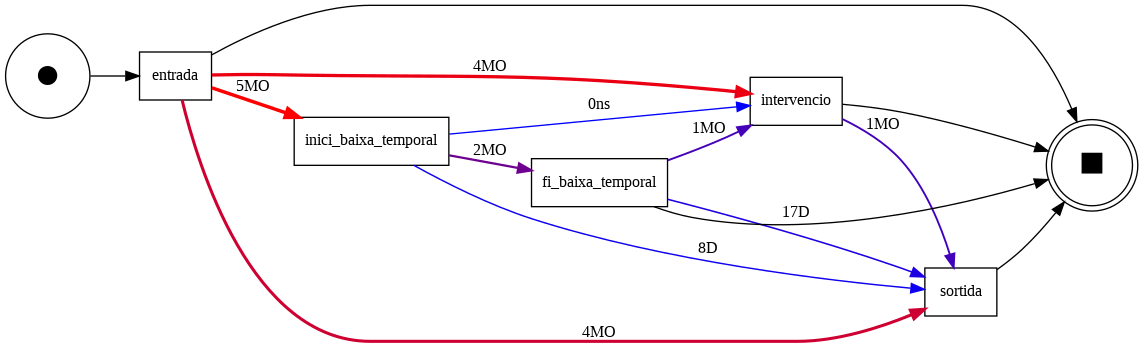

In [56]:
performance_map = pm4py.discover_performance_dfg(df_event_log_final,
                                                 case_id_key='id_episodi',
                                                 activity_key='event',
                                                 timestamp_key='data_event')

pm4py.view_performance_dfg(performance_map[0], performance_map[1], performance_map[2])

El nou gràfic mostra un flux coherent i alineat amb el procés assistencial esperat.

S’observa que els temps més elevats es concentren en les transicions entre l’entrada en llista d’espera i l’inici de la baixa temporal, així com entre l’entrada i la resolució del procés (intervenció o sortida).

IDENTIFICACIÓ QUANTITATIVA DE COLLS D'AMPOLLA

In [57]:
# Ordenem cronològicament
df_bottleneck = df_event_log_final.sort_values(
    ["id_episodi", "data_event"]
).copy()

# Event següent dins del mateix episodi
df_bottleneck["next_event"] = (
    df_bottleneck.groupby("id_episodi")["event"]
    .shift(-1)
)

# Timestamp següent
df_bottleneck["next_timestamp"] = (
    df_bottleneck.groupby("id_episodi")["data_event"]
    .shift(-1)
)

# Calculem temps entre activitats consecutives
df_bottleneck["temps_transicio"] = (
    df_bottleneck["next_timestamp"] -
    df_bottleneck["data_event"]
).dt.total_seconds() / 86400

# Eliminem files sense següent event
df_bottleneck = df_bottleneck[
    df_bottleneck["next_event"].notna()
]

# Nom transició
df_bottleneck["transicio"] = (
    df_bottleneck["event"] +
    " -> " +
    df_bottleneck["next_event"]
)

# Temps mitjà per transició
df_bottlenecks = (
    df_bottleneck
    .groupby("transicio")["temps_transicio"]
    .mean()
    .reset_index()
)

# Renombrar columna
df_bottlenecks = df_bottlenecks.rename(columns={
    "temps_transicio": "temps_mitja_dies"
})

# Ordenar
df_bottlenecks = df_bottlenecks.sort_values(
    by="temps_mitja_dies",
    ascending=False
)

# Resultats
df_bottlenecks

,transicio,temps_mitja_dies
0,entrada -> inici_baixa_temporal,155.521907
1,entrada -> intervencio,143.529073
2,entrada -> sortida,125.258460
5,inici_baixa_temporal -> fi_baixa_temporal,67.141956
3,fi_baixa_temporal -> intervencio,42.164948
8,intervencio -> sortida,40.333333
4,fi_baixa_temporal -> sortida,17.479592
7,inici_baixa_temporal -> sortida,8.603939
6,inici_baixa_temporal -> intervencio,0.000000


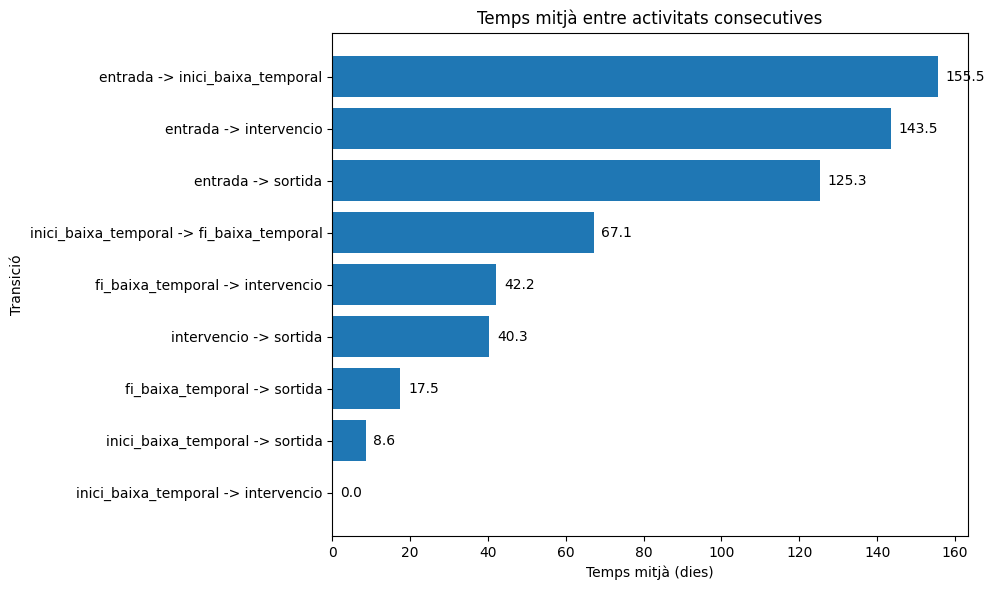

In [58]:
# GRÀFIC COLLS D'AMPOLLA

# Assegurar ordre correcte
df_plot = df_bottlenecks.sort_values(
    by="temps_mitja_dies",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    df_plot["transicio"],
    df_plot["temps_mitja_dies"]
)

plt.title("Temps mitjà entre activitats consecutives")
plt.xlabel("Temps mitjà (dies)")
plt.ylabel("Transició")

# Etiquetes
for i, v in enumerate(df_plot["temps_mitja_dies"]):
    plt.text(v + 2, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

**Anàlisi per grups**

Com que cada grup d’intervenció presenta terminis de garantia diferents en funció de la seva prioritat clínica, s'analitzarà el comportament del procés de manera desagregada per grup.

ANÀLISI DE VARIANTS PER GRUP

In [59]:
grups = [
    'Garantia',
    'Oncologia 45 dies',
    'Oncologia 60 dies'
]

resum_variants = []

for grup in grups:

    print("\n" + "="*60)
    print(f"ANÀLISI DE VARIANTS: {grup.upper()}")
    print("="*60)

    # Filtrar grup
    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ]

    # MÈTRIQUES BÀSIQUES

    n_casos = df_grup["id_episodi"].nunique()

    n_events = len(df_grup)

    events_per_case = (
        df_grup.groupby("id_episodi")
        .size()
        .mean()
    )

    print(f"Casos: {n_casos}")
    print(f"Esdeveniments totals: {n_events}")
    print(f"Mitjana events/cas: {events_per_case:.2f}")

    # ANÀLISI DE VARIANTS

    variants = pm4py.get_variants(df_grup)

    print(f"Variants diferents: {len(variants)}")

    # Construcció taula variants
    variants_count = []

    for variant, casos in variants.items():

        variants_count.append({
            "variant": " -> ".join(variant),
            "casos": casos
        })

    df_variants = pd.DataFrame(variants_count)

    df_variants = df_variants.sort_values(
        by="casos",
        ascending=False
    )

    # Mostrar top variants
    print("\nTop variants:")
    print(df_variants.head(10))

    resum_variants.append({
        "grup": grup,
        "casos": n_casos,
        "variants": len(variants),
        "mitjana_events_cas": round(events_per_case, 2)
    })

# TAULA COMPARATIVA FINAL
df_resum_variants = pd.DataFrame(resum_variants)

print("\n" + "="*60)
print("RESUM COMPARATIU")
print("="*60)

df_resum_variants


ANÀLISI DE VARIANTS: GARANTIA
Casos: 8309
Esdeveniments totals: 16646
Mitjana events/cas: 2.00
Variants diferents: 9

Top variants:
                                             variant  casos
1                             entrada -> intervencio   5244
3                                 entrada -> sortida   1571
5                                            entrada    851
4         entrada -> inici_baixa_temporal -> sortida    380
2  entrada -> inici_baixa_temporal -> fi_baixa_te...    163
0  entrada -> inici_baixa_temporal -> fi_baixa_te...     71
6  entrada -> inici_baixa_temporal -> fi_baixa_te...     23
7                  entrada -> intervencio -> sortida      4
8  entrada -> inici_baixa_temporal -> intervencio...      2

ANÀLISI DE VARIANTS: ONCOLOGIA 45 DIES
Casos: 937
Esdeveniments totals: 1908
Mitjana events/cas: 2.04
Variants diferents: 7

Top variants:
                                             variant  casos
2                             entrada -> intervencio    828
3      

,grup,casos,variants,mitjana_events_cas
0,Garantia,8309,9,2.00
1,Oncologia 45 dies,937,7,2.04
2,Oncologia 60 dies,928,6,2.11


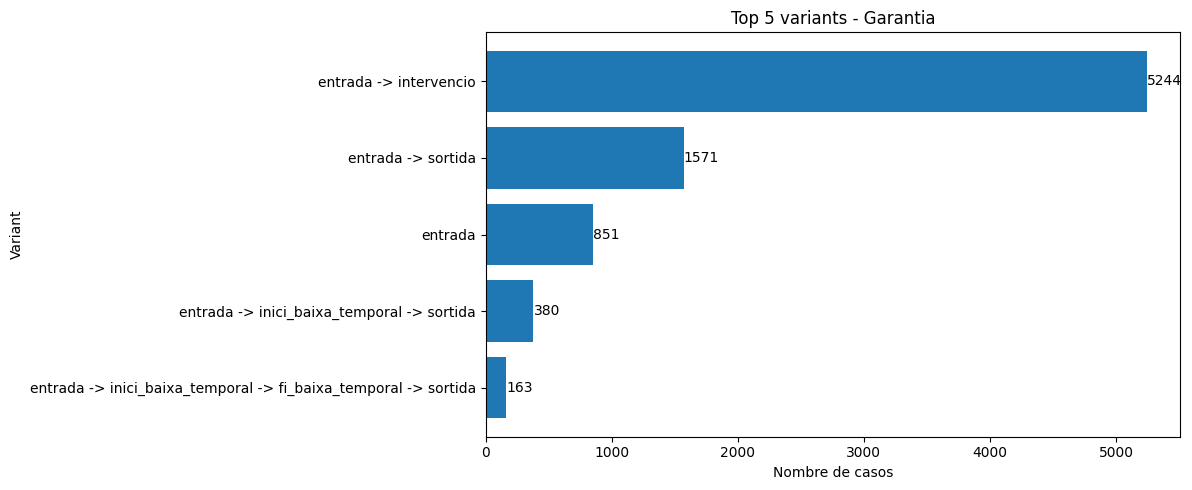

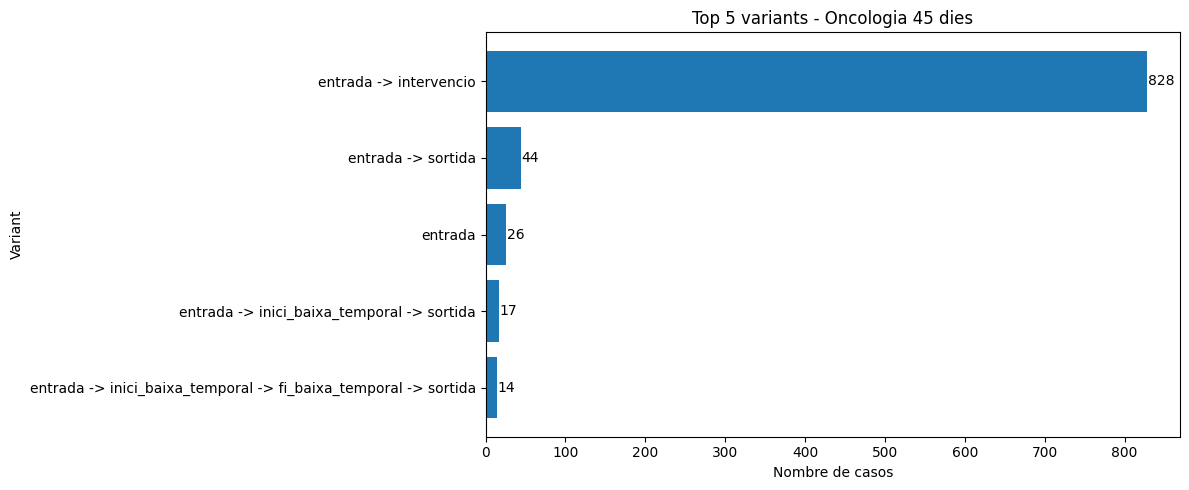

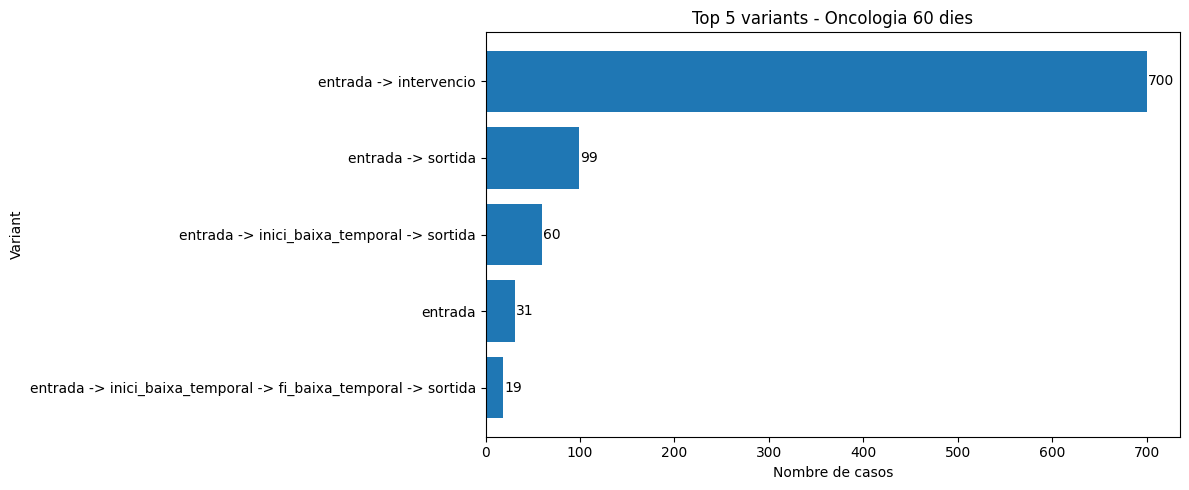

In [60]:
grups = [
    'Garantia',
    'Oncologia 45 dies',
    'Oncologia 60 dies'
]

for grup in grups:

    # Filtrar grup
    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ]

    # Obtenir variants
    variants = pm4py.get_variants(df_grup)

    # Construir dataframe
    variants_count = []

    for variant, casos in variants.items():

        variants_count.append({
            "variant": " -> ".join(variant),
            "casos": casos
        })

    df_variants = pd.DataFrame(variants_count)

    # TOP 5 variants
    df_plot = (
        df_variants
        .sort_values(by="casos", ascending=False)
        .head(5)
        .sort_values(by="casos", ascending=True)
    )

    # Crear gràfic
    plt.figure(figsize=(12,5))

    plt.barh(
        df_plot["variant"],
        df_plot["casos"]
    )

    # Títols
    plt.title(f"Top 5 variants - {grup}")
    plt.xlabel("Nombre de casos")
    plt.ylabel("Variant")

    # Etiquetes
    for i, v in enumerate(df_plot["casos"]):
        plt.text(v + 1, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

,Garantia,Oncologia 45 dies,Oncologia 60 dies
entrada -> intervencio,5244,828,700
entrada -> sortida,1571,44,99
entrada,851,26,31
entrada -> inici_baixa_temporal -> sortida,380,17,60
entrada -> inici_baixa_temporal -> fi_baixa_temporal -> sortida,163,14,19


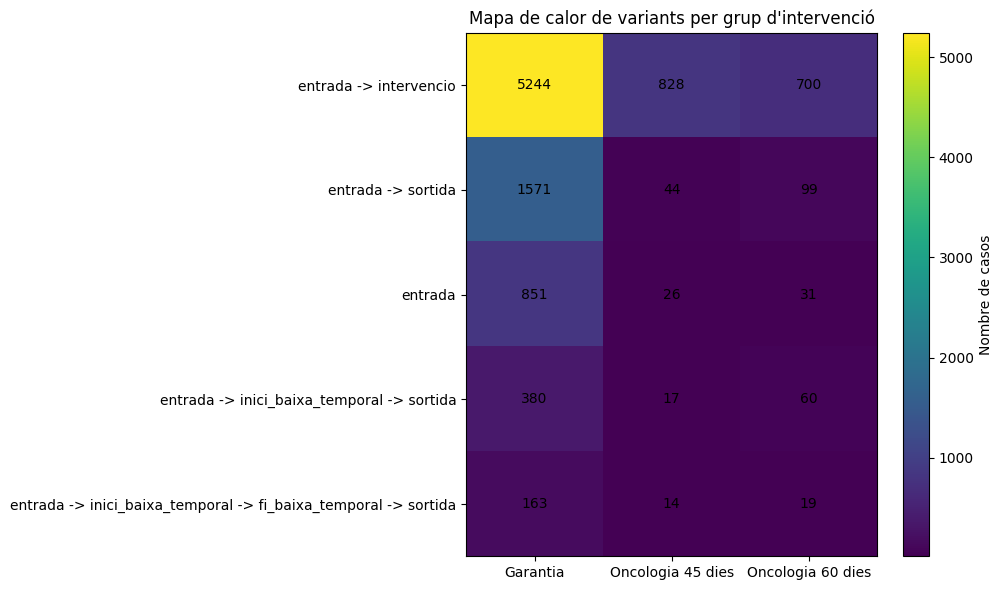

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

grups = [
    'Garantia',
    'Oncologia 45 dies',
    'Oncologia 60 dies'
]

# =========================
# OBTENIR TOP 5 VARIANTS GLOBALS
# =========================

variants_totals = {}

for grup in grups:

    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ]

    variants = pm4py.get_variants(df_grup)

    for variant, casos in variants.items():

        nom_variant = " -> ".join(variant)

        if nom_variant not in variants_totals:
            variants_totals[nom_variant] = 0

        variants_totals[nom_variant] += casos

# DataFrame totals
df_totals = pd.DataFrame({
    "variant": variants_totals.keys(),
    "casos_totals": variants_totals.values()
})

# Top 5 variants
top_variants = (
    df_totals
    .sort_values(by="casos_totals", ascending=False)
    .head(5)["variant"]
    .tolist()
)

# =========================
# CREAR MATRIU
# =========================

matriu = pd.DataFrame(index=top_variants)

for grup in grups:

    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ]

    variants = pm4py.get_variants(df_grup)

    variants_dict = {
        " -> ".join(v): c
        for v, c in variants.items()
    }

    matriu[grup] = [
        variants_dict.get(v, 0)
        for v in top_variants
    ]

# Mostrar matriu
display(matriu)

# =========================
# MAPA DE CALOR
# =========================

plt.figure(figsize=(10,6))

plt.imshow(matriu, aspect='auto')

# Etiquetes eixos
plt.xticks(
    range(len(matriu.columns)),
    matriu.columns,
    rotation=0
)

plt.yticks(
    range(len(matriu.index)),
    matriu.index
)

# Barra lateral color
plt.colorbar(label="Nombre de casos")

# Títol
plt.title("Mapa de calor de variants per grup d'intervenció")

# Afegir valors dins cel·les
for i in range(len(matriu.index)):
    for j in range(len(matriu.columns)):

        plt.text(
            j,
            i,
            matriu.iloc[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

Per a cada grup, es calculen els temps totals per episodi i es generen representacions del procés mitjançant Heuristic Miner i Directly-Follows Graph (DFG) de rendiment.


ANÀLISI COMPLETA: GARANTIA

[1] Generant Heuristic Miner per a Garantia...


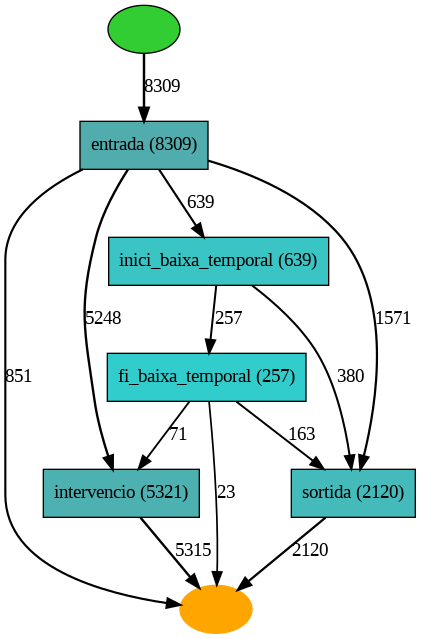

[2] Generant Performance DFG per a Garantia...


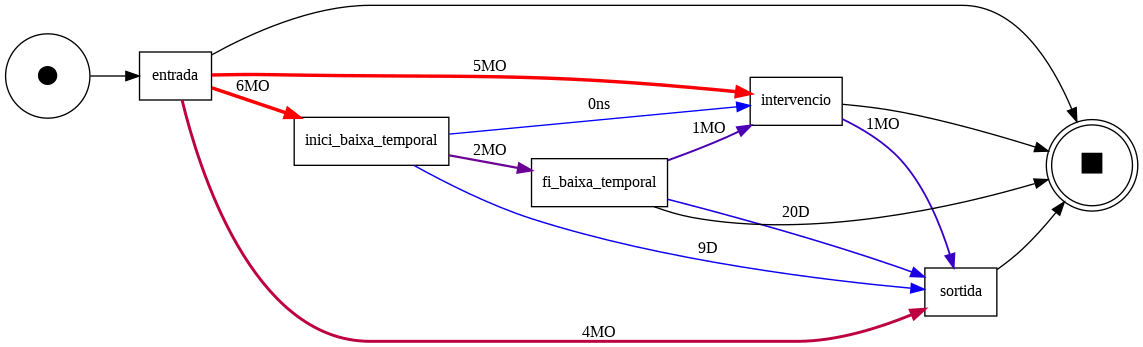


ANÀLISI COMPLETA: ONCOLOGIA 45 DIES

[1] Generant Heuristic Miner per a Oncologia 45 dies...


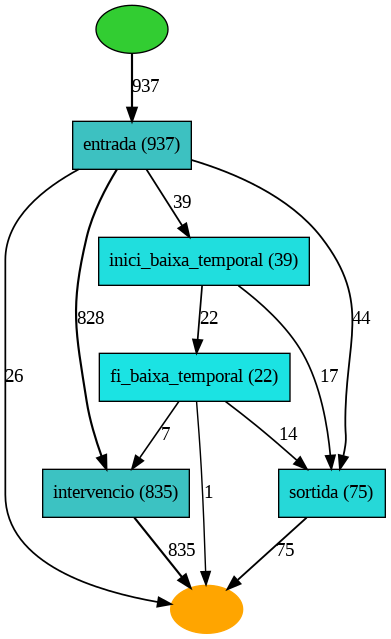

[2] Generant Performance DFG per a Oncologia 45 dies...


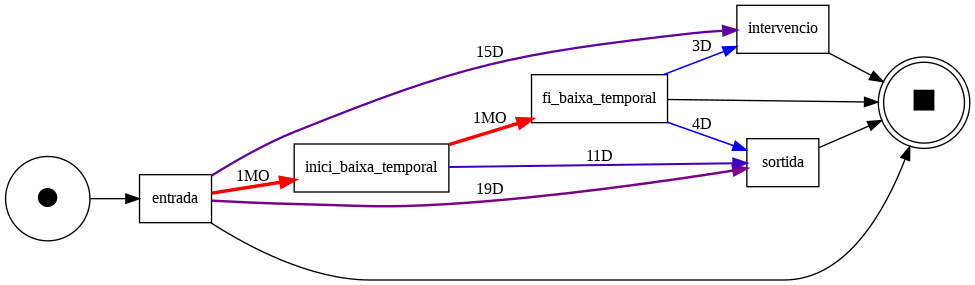


ANÀLISI COMPLETA: ONCOLOGIA 60 DIES

[1] Generant Heuristic Miner per a Oncologia 60 dies...


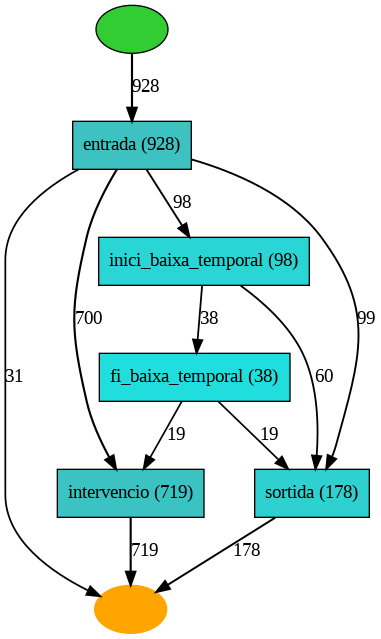

[2] Generant Performance DFG per a Oncologia 60 dies...


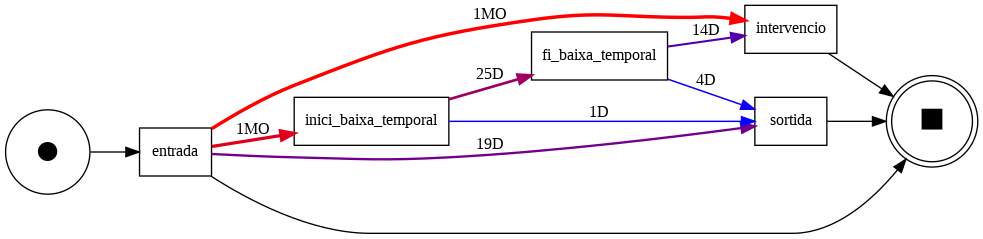


------------------------------
TAULA COMPARATIVA FINAL
------------------------------
             Grup  Casos  Mitjana (dies)  Mediana (dies)
         Garantia   8309          155.18           162.0
Oncologia 45 dies    937           17.61            11.0
Oncologia 60 dies    928           37.73            38.0


In [62]:
import numpy as np

resum = []

for grup in grups:
    # Filtrar les dades pel grup actual
    df_grup = df_event_log_final[df_event_log_final['grup_intervencio'] == grup]

    if len(df_grup) > 0:
        print(f"\n" + "="*60)
        print(f"ANÀLISI COMPLETA: {grup.upper()}")
        print(f"="*60)

        # Càlcul d'estadístiques per a la taula resum
        case_durations = pm4py.get_all_case_durations(df_grup)
        durations_days = [d / 86400 for d in case_durations]

        resum.append({
            "Grup": grup,
            "Casos": df_grup['id_episodi'].nunique(),
            "Mitjana (dies)": round(np.mean(durations_days), 2),
            "Mediana (dies)": round(np.median(durations_days), 2)
        })

        # VISUALITZACIÓ 1: Heuristic Miner
        print(f"\n[1] Generant Heuristic Miner per a {grup}...")
        heu_net = pm4py.discover_heuristics_net(
            df_grup,
            case_id_key='id_episodi',
            activity_key='event',
            timestamp_key='data_event'
        )
        pm4py.view_heuristics_net(heu_net)

        # VISUALITZACIÓ 2: DFG
        print(f"[2] Generant Performance DFG per a {grup}...")
        dfg_perf, sa, ea = pm4py.discover_performance_dfg(
            df_grup,
            case_id_key='id_episodi',
            activity_key='event',
            timestamp_key='data_event'
        )
        pm4py.view_performance_dfg(dfg_perf, sa, ea)

# Mostrar la taula comparativa final per tancar l'anàlisi
df_comparatiu = pd.DataFrame(resum)
print("\n" + "-"*30)
print("TAULA COMPARATIVA FINAL")
print("-"*30)
print(df_comparatiu.to_string(index=False))

El temps analitzats en la taula comparativa correspon a la durada total de cada episodi dins del procés assistencial, calculat com el temps transcorregut entre el primer i l’últim esdeveniment registrat per a cada cas. En concret, mesura el període des de l’entrada del pacient a la llista d’espera, fins a la seva resolució definitiva, que pot ser la intervenció quirúrgica o la sortida de la llista (per exemple, per trasllat o baixa).

Els resultats mostren diferències rellevants entre grups d’intervenció.

**Garantia**

Aquest grup presenta el major volum d’activitat (8.309 episodis) i uns temps d’espera elevats, amb una mitjana de 155 dies i una mediana de 162 dies, fet que indica una distribució relativament homogènia dels temps.

L’anàlisi del procés mostra que el flux principal és directe cap a la intervenció (5.248 casos), tot i que també s’observen trajectòries amb baixa temporal.

A més, es detecta un volum rellevant de pacients que no arriben a ser intervinguts i surten del sistema (1.571 casos), així com un nombre considerable de pacients que es troben encara en llista d’espera en el moment de l’anàlisi (851 casos).

Pel que fa als temps entre esdeveniments, destaca especialment el període entre l’entrada i l’inici de la baixa temporal, amb una durada aproximada de 6 mesos (180 dies). Aquest fet suggereix que molts pacients passen a situació de baixa temporal quan estan a prop o han superat el termini de garantia.

Un cop el pacient entra en baixa temporal, hi roman aproximadament 2 mesos, i després de la seva finalització, la resolució és relativament ràpida, amb una intervenció o sortida del sistema en aproximadament 1 mes.

Finalment, també s’observa un temps mitjà de 4 mesos entre l’entrada i la intervenció, valor que, tot i ser levat, es manté dins del termini de garantia establert.

**Oncologia 45 dies**

Aquest grup presenta un volum d’activitat menor (937 episodis) i uns temps d’espera molt reduïts, amb una mitjana aproximada de 17 dies i una mediana de 11 dies, clarament per sota del termini de garantia establert (45 dies).

L’anàlisi del procés mostra que el flux principal és directe cap a la intervenció (828 casos)i les trajectòries amb baixa temporal són poc freqüents (39 casos). També s’observa un nombre reduït de pacients que surten del sistema sense intervenció (44 casos), així com un volum molt baix de casos encara oberts (26).

Pel que fa als temps entre esdeveniments, el període entre l’entrada i la intervenció és aproximadament de 15 dies, confirmant la rapidesa del procés. En els casos amb baixa temporal, el temps fins a l’inici de la baixa és d’aproximadament 1 mes, i la durada d’aquesta és també al voltant d’1 mes. Un cop finalitzada la baixa temporal, la resolució és molt ràpida, amb intervencions en aproximadament 3 dies.

**Oncologia 60 dies**

Aquest grup presenta un volum d’activitat de 928 episodis i uns temps d’espera reduïts, amb una mitjana aproximada de 37 dies i una mediana de 38 dies, situant-se dins del termini de garantia establert (60 dies).

L’anàlisi del procés mostra que el flux principal és directe cap a la intervenció (700 casos). S’observa 98 casos amb baixa temporal, així com 99 pacients que surten del sistema sense intervenció.

Pel que fa als temps entre esdeveniments, el període entre l’entrada i la intervenció és aproximadament d’1 mes. En els casos amb baixa temporal, el temps fins a l’inici de la baixa és també d’aproximadament 1 mes, mentre que la durada d’aquesta se situa al voltant de 25 dies. Un cop finalitzada la baixa temporal, la resolució es produeix en aproximadament 14 dies fins a la intervenció.

IDENTIFICACIÓ QUANTITATIVA DE COLLS D'AMPOLLA PER GRUP

In [63]:
for grup in grups:

    print("\n" + "="*60)
    print(f"COLLS D'AMPOLLA: {grup.upper()}")
    print("="*60)

    # Filtrar grup
    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ].copy()

    # ORDENACIÓ TEMPORAL

    df_grup = df_grup.sort_values(
        ["id_episodi", "data_event"]
    )

    # Event següent dins del mateix cas
    df_grup["next_event"] = (
        df_grup.groupby("id_episodi")["event"]
        .shift(-1)
    )

    # Timestamp següent
    df_grup["next_timestamp"] = (
        df_grup.groupby("id_episodi")["data_event"]
        .shift(-1)
    )

    # TEMPS ENTRE TRANSICIONS

    df_grup["temps_transicio"] = (
        df_grup["next_timestamp"] -
        df_grup["data_event"]
    ).dt.total_seconds() / 86400

    # Eliminem files sense següent event
    df_grup = df_grup[
        df_grup["next_event"].notna()
    ]

    # Nom de la transició
    df_grup["transicio"] = (
        df_grup["event"] +
        " -> " +
        df_grup["next_event"]
    )

    # TEMPS MITJÀ PER TRANSICIÓ

    df_bottlenecks = (
        df_grup
        .groupby("transicio")["temps_transicio"]
        .mean()
        .reset_index()
    )

    # Renombrar columna
    df_bottlenecks = df_bottlenecks.rename(columns={
        "temps_transicio": "temps_mitja_dies"
    })

    # Ordenar de major a menor
    df_bottlenecks = df_bottlenecks.sort_values(
        by="temps_mitja_dies",
        ascending=False
    )

    # RESULTATS
    print(df_bottlenecks)


COLLS D'AMPOLLA: GARANTIA
                                   transicio  temps_mitja_dies
0            entrada -> inici_baixa_temporal        181.197183
1                     entrada -> intervencio        177.435785
2                         entrada -> sortida        134.914067
5  inici_baixa_temporal -> fi_baixa_temporal         75.929961
3           fi_baixa_temporal -> intervencio         53.422535
8                     intervencio -> sortida         40.333333
4               fi_baixa_temporal -> sortida         20.202454
7            inici_baixa_temporal -> sortida          9.576316
6        inici_baixa_temporal -> intervencio          0.000000

COLLS D'AMPOLLA: ONCOLOGIA 45 DIES
                                   transicio  temps_mitja_dies
5  inici_baixa_temporal -> fi_baixa_temporal         36.500000
0            entrada -> inici_baixa_temporal         35.974359
2                         entrada -> sortida         19.159091
1                     entrada -> intervencio         15


COLLS D'AMPOLLA: GARANTIA


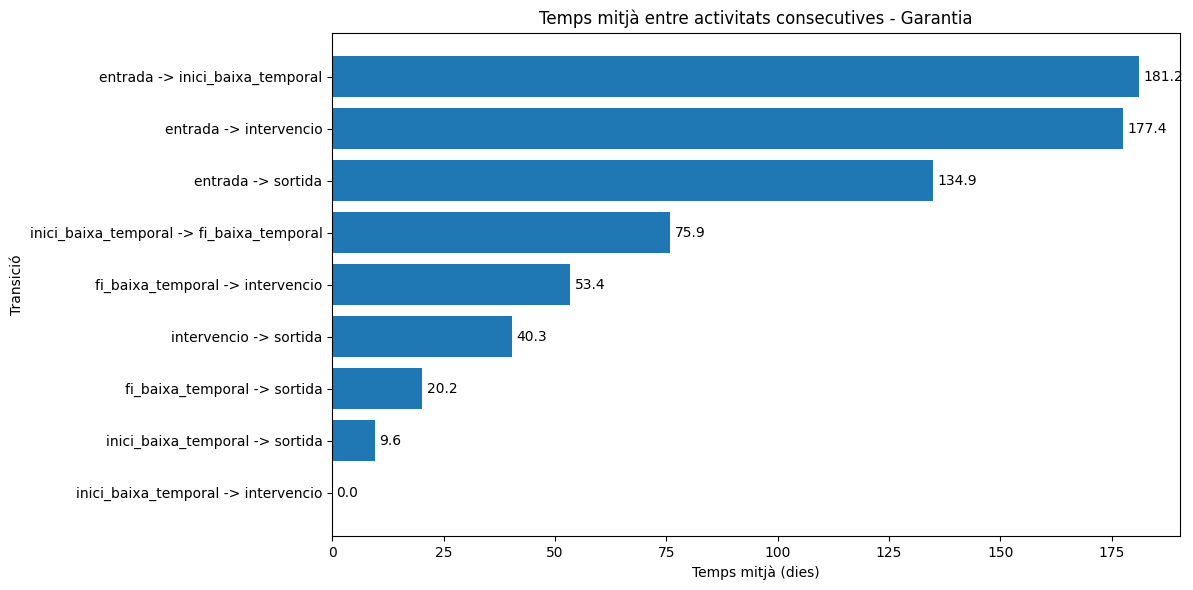


COLLS D'AMPOLLA: ONCOLOGIA 45 DIES


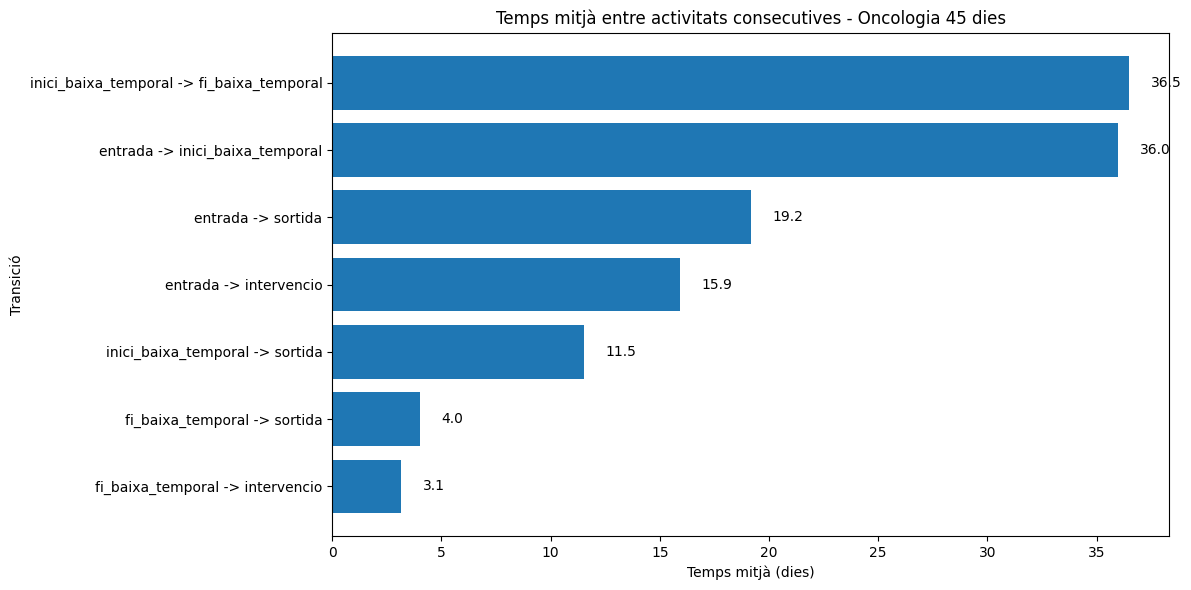


COLLS D'AMPOLLA: ONCOLOGIA 60 DIES


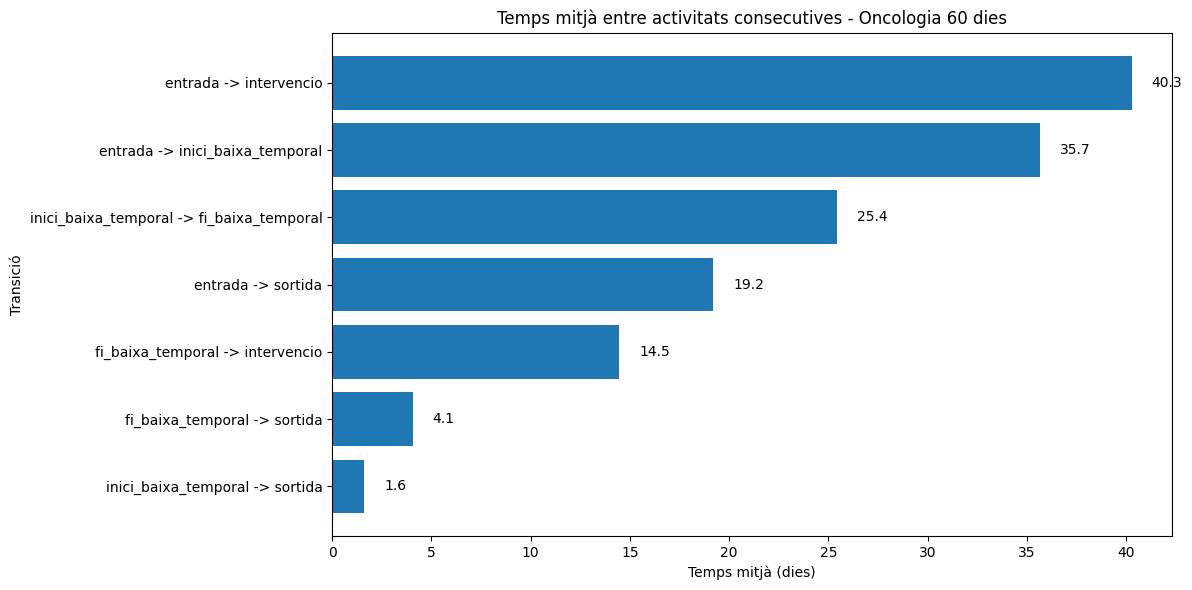

In [64]:
for grup in grups:

    print("\n" + "="*60)
    print(f"COLLS D'AMPOLLA: {grup.upper()}")
    print("="*60)

    # Filtrar grup
    df_grup = df_event_log_final[
        df_event_log_final["grup_intervencio"] == grup
    ].copy()

    # Ordenació temporal
    df_grup = df_grup.sort_values(
        ["id_episodi", "data_event"]
    )

    # Event següent
    df_grup["next_event"] = (
        df_grup.groupby("id_episodi")["event"]
        .shift(-1)
    )

    # Timestamp següent
    df_grup["next_timestamp"] = (
        df_grup.groupby("id_episodi")["data_event"]
        .shift(-1)
    )

    # Temps entre transicions
    df_grup["temps_transicio"] = (
        df_grup["next_timestamp"] -
        df_grup["data_event"]
    ).dt.total_seconds() / 86400

    # Eliminar files sense següent event
    df_grup = df_grup[
        df_grup["next_event"].notna()
    ]

    # Nom transició
    df_grup["transicio"] = (
        df_grup["event"] +
        " -> " +
        df_grup["next_event"]
    )

    # Temps mitjà per transició
    df_bottlenecks = (
        df_grup
        .groupby("transicio")["temps_transicio"]
        .mean()
        .reset_index()
    )

    # Renombrar columna
    df_bottlenecks = df_bottlenecks.rename(columns={
        "temps_transicio": "temps_mitja_dies"
    })

    # TOP 10 colls d'ampolla
    df_plot = (
        df_bottlenecks
        .sort_values(by="temps_mitja_dies", ascending=True)
        .tail(10)
    )

    # =========================
    # GRÀFIC
    # =========================

    plt.figure(figsize=(12,6))

    plt.barh(
        df_plot["transicio"],
        df_plot["temps_mitja_dies"]
    )

    plt.title(f"Temps mitjà entre activitats consecutives - {grup}")
    plt.xlabel("Temps mitjà (dies)")
    plt.ylabel("Transició")

    # Etiquetes
    for i, v in enumerate(df_plot["temps_mitja_dies"]):
        plt.text(v + 1, i, f"{v:.1f}", va='center')

    plt.tight_layout()
    plt.show()

# Anàlisi motius de sortida

Per què els pacients surten sense ser operats?

In [65]:
# Visió general
(df_episodi["Motiu de baixa"].value_counts(normalize=True) * 100).round(2)

,proportion
Motiu de baixa,
Activitat realitzada,71.55
Trasllat a un altre centre,11.29
Sense especificar,9.30
Baixa voluntària del pacient,3.29
Baixa tècnica,1.54
Contraindicació mèdica,0.82
Èxitus SRD (no confirmat Reg defuncions),0.77
Activitat realitzada d'urgència,0.63
Pacient sol·licita o accepta demora,0.37


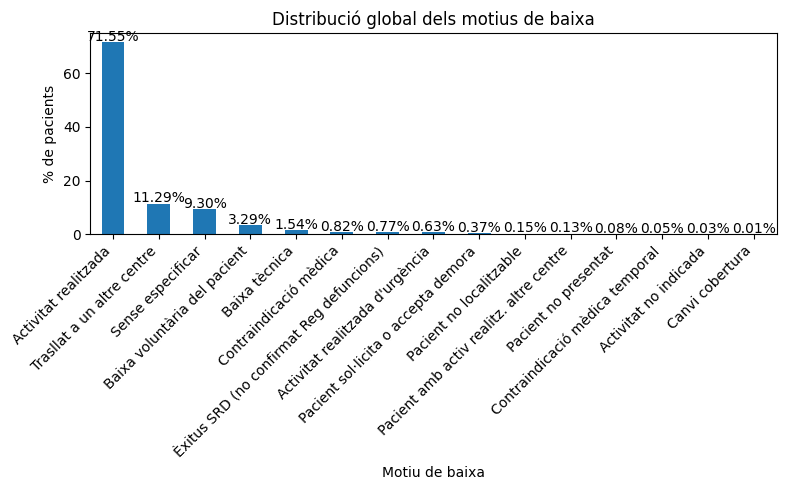

In [66]:
# Calcular percentatges
df_plot_global = (
    df_episodi["Motiu de baixa"]
    .value_counts(normalize=True)
    * 100
)

# Gràfic
ax = df_plot_global.plot(kind="bar", figsize=(8,5))

plt.title("Distribució global dels motius de baixa")
plt.xlabel("Motiu de baixa")
plt.ylabel("% de pacients")
plt.xticks(rotation=45, ha="right")

# Afegir etiquetes amb %
for i, v in enumerate(df_plot_global):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

Els resultats mostren que el 71,55% dels episodis finalitzen amb “activitat realitzada”, fet que indica que la majoria de pacients acaben sent intervinguts.

Pel que fa als casos en què no es realitza la intervenció, el principal motiu és el trasllat a un altre centre (11,29%), la qual cosa suggereix possibles limitacions de capacitat o derivacions a altres proveïdors.

Destaca també un 9,30% de casos sense especificació del motiu de baixa, fet que posa de manifest una limitació en la qualitat del registre de dades i que pot dificultar una interpretació més precisa del procés.

Altres motius rellevants inclouen la baixa voluntària del pacient (3,29%) i la baixa tècnica (1,54%), que poden estar associats a decisions del pacient o a aspectes organitzatius.

A continuació s'analitzen els motius de baixa desagregats per grup d'intervenció.

In [67]:
# Per grup d'intervenció
(df_episodi.groupby("grup_intervencio")["Motiu de baixa"].value_counts(normalize=True) * 100).round(2)

grup_intervencio   Motiu de baixa                          
Garantia           Activitat realitzada                        68.01
                   Trasllat a un altre centre                  13.13
                   Sense especificar                           10.68
                   Baixa voluntària del pacient                 3.67
                   Baixa tècnica                                1.44
                   Èxitus SRD (no confirmat Reg defuncions)     0.84
                   Activitat realitzada d'urgència              0.65
                   Contraindicació mèdica                       0.63
                   Pacient sol·licita o accepta demora          0.43
                   Pacient no localitzable                      0.18
                   Pacient amb activ realitz. altre centre      0.14
                   Pacient no presentat                         0.10
                   Contraindicació mèdica temporal              0.06
                   Activitat no indicada                        0.02
                   Canvi cobertura                              0.01
Oncologia 45 dies  Activitat realitzada                        90.61
                   Sense especificar                            2.99
                   Baixa tècnica                                2.24
                   Contraindicació mèdica                       1.28
                   Baixa voluntària del pacient                 1.17
                   Trasllat a un altre centre                   1.07
                   Pacient sol·licita o accepta demora          0.21
                   Èxitus SRD (no confirmat Reg defuncions)     0.21
                   Activitat no indicada                        0.11
                   Activitat realitzada d'urgència              0.11
Oncologia 60 dies  Activitat realitzada                        83.94
                   Trasllat a un altre centre                   5.17
                   Sense especificar                            3.34
                   Baixa voluntària del pacient                 2.05
                   Contraindicació mèdica                       2.05
                   Baixa tècnica                                1.72
                   Activitat realitzada d'urgència              0.97
                   Èxitus SRD (no confirmat Reg defuncions)     0.65
                   Pacient amb activ realitz. altre centre      0.11
Name: proportion, dtype: float64

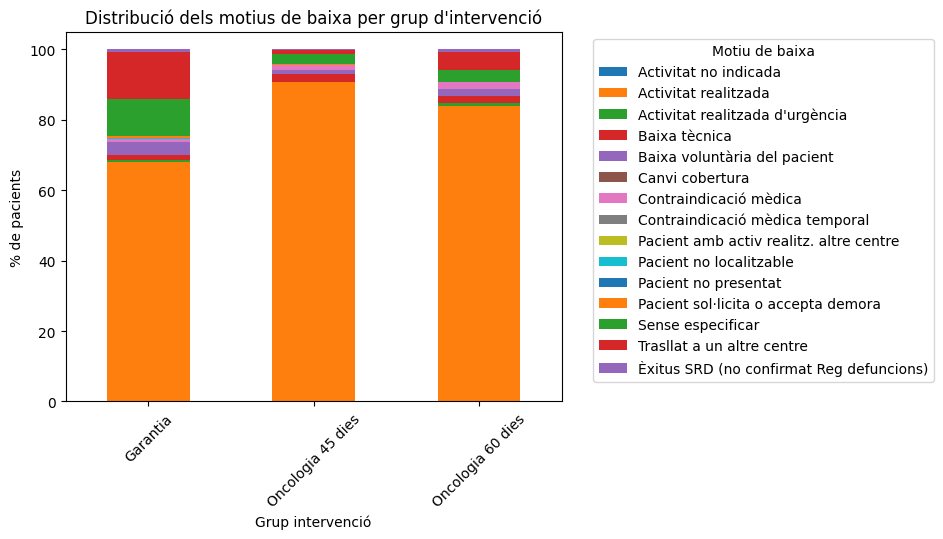

In [68]:
# Gràfic
df_plot = (
    df_episodi.groupby("grup_intervencio")["Motiu de baixa"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

# Gràfic
df_plot.plot(kind="bar", stacked=True)

plt.title("Distribució dels motius de baixa per grup d'intervenció")
plt.xlabel("Grup intervenció")
plt.ylabel("% de pacients")
plt.xticks(rotation=45)
plt.legend(title="Motiu de baixa", bbox_to_anchor=(1.05, 1))

plt.show()

En el grup de **Garantia**, el percentatge d’episodis que finalitzen amb intervenció és inferior (68,01%) en comparació amb els grups oncològics. En aquest grup destaca un volum elevat de trasllats a altres centres (13,13%) i de casos sense especificar (10,68%), així com una major presència de baixes voluntàries del pacient (3,67%).

En el grup d’**Oncologia 45 dies**, el percentatge d’activitat realitzada és molt elevat (90,61%), indicant un procés altament eficient i alineat amb la prioritat clínica. La resta de motius de baixa tenen un pes molt reduït.

Pel que fa al grup d’**Oncologia 60 dies**, el percentatge d’intervencions també és alt (83,94%), tot i que inferior al grup d’Oncologia 45 dies. S’observa una lleugera major diversitat de motius de baixa, amb presència de trasllats (5,17%), baixes voluntàries (2,05%) i contraindicacions mèdiques (2,05%).




Per acabar, analitzem els motius de sortida per tipus dintervenció.

In [69]:
# Per procediment
pd.set_option('display.max_rows', None)
(df_episodi.groupby("procediment")["Motiu de baixa"].value_counts(normalize=True) * 100).round(2)

procediment                               Motiu de baixa                          
Intervenció de cataracta                  Activitat realitzada                         69.43
                                          Trasllat a un altre centre                   12.79
                                          Sense especificar                            11.14
                                          Baixa voluntària del pacient                  3.39
                                          Baixa tècnica                                 1.36
                                          Èxitus SRD (no confirmat Reg defuncions)      0.93
                                          Contraindicació mèdica                        0.43
                                          Pacient no localitzable                       0.19
                                          Pacient no presentat                          0.12
                                          Pacient amb activ realitz. altre centre       0.09
                                          Pacient sol·licita o accepta demora           0.04
                                          Activitat no indicada                         0.03
                                          Contraindicació mèdica temporal               0.03
                                          Activitat realitzada d'urgència               0.01
                                          Canvi cobertura                               0.01
Neo malignes hemat. i del sist. limfàtic  Activitat realitzada                         50.00
                                          Sense especificar                            50.00
Neo. maligna de matriu, ovaris i annexos  Activitat realitzada                         92.31
                                          Contraindicació mèdica                        7.69
Neo. maligna de ronyó i vies urinàries    Activitat realitzada                         66.67
                                          Sense especificar                            11.67
                                          Trasllat a un altre centre                   10.00
                                          Contraindicació mèdica                        5.00
                                          Pacient sol·licita o accepta demora           3.33
                                          Baixa tècnica                                 1.67
                                          Baixa voluntària del pacient                  1.67
Neoplàsia maligna altres localitzacions   Activitat realitzada                         80.95
                                          Sense especificar                             9.52
                                          Trasllat a un altre centre                    9.52
Neoplàsia maligna altres òrgans genitals  Activitat realitzada                         94.12
                                          Trasllat a un altre centre                    5.88
Neoplàsia maligna de bufeta               Activitat realitzada                         84.50
                                          Trasllat a un altre centre                    4.68
                                          Sense especificar                             3.46
                                          Contraindicació mèdica                        2.01
                                          Baixa voluntària del pacient                  1.90
                                          Baixa tècnica                                 1.67
                                          Activitat realitzada d'urgència               1.00
                                          Èxitus SRD (no confirmat Reg defuncions)      0.67
                                          Pacient amb activ realitz. altre centre       0.11
Neoplàsia maligna de cap i de coll        Activitat realitzada                        100.00
Neoplàsia maligna de còlon                Activitat realitzada                         92.22
           

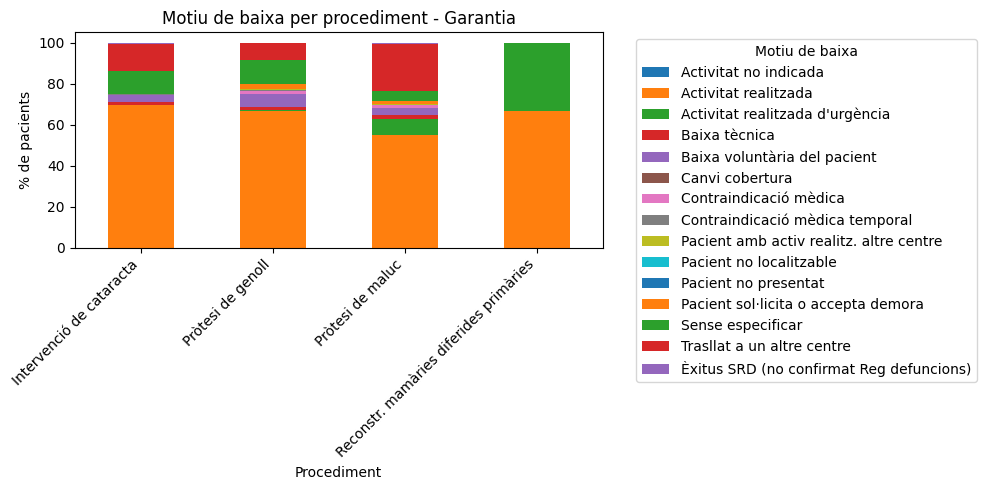

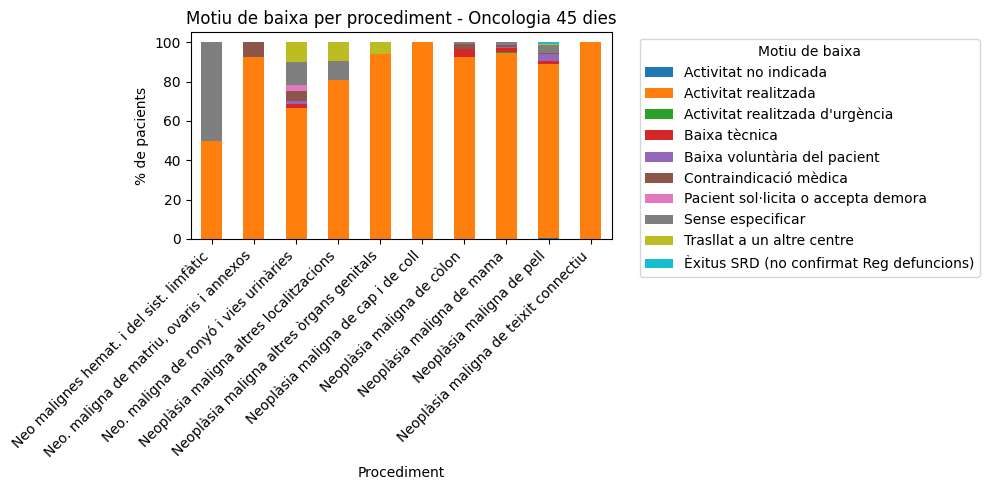

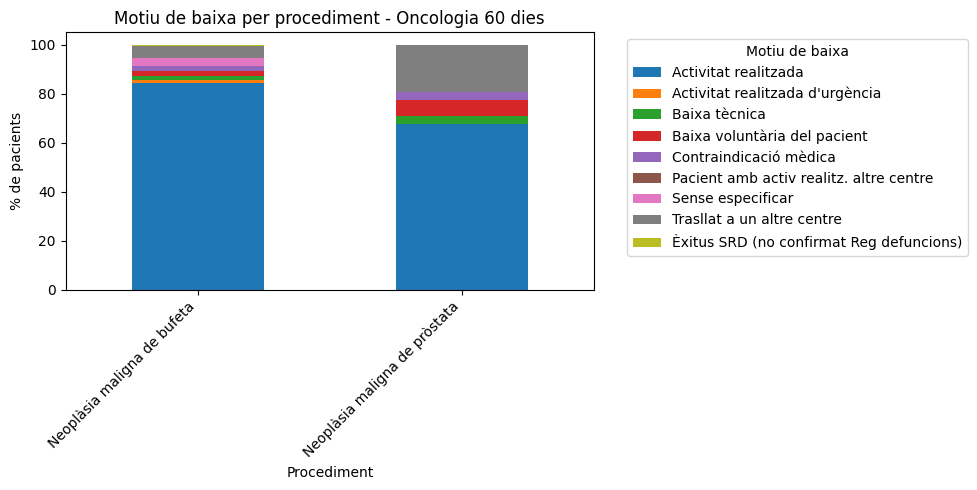

In [70]:
# Llista de grups
grups = df_episodi["grup_intervencio"].unique()

for grup in grups:

    # Filtrar dades del grup
    df_grup = df_episodi[df_episodi["grup_intervencio"] == grup]

    # Taula en %
    df_plot = (
        df_grup.groupby("procediment")["Motiu de baixa"]
        .value_counts(normalize=True)
        .unstack()
        * 100
    )

    # Gràfic
    ax = df_plot.plot(kind="bar", stacked=True, figsize=(10,5))

    plt.title(f"Motiu de baixa per procediment - {grup}")
    plt.xlabel("Procediment")
    plt.ylabel("% de pacients")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Motiu de baixa", bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()

En procediments de gran volum com la **intervenció de cataracta**, el percentatge d’activitat realitzada és del 69,43%, amb una presència significativa de trasllats a altres centres (12,79%) i de casos sense especificar (11,14%).

En les **pròtesis de maluc**, s’observa el percentatge més baix d’activitat realitzada (55,07%), amb un volum molt elevat de trasllats (22,69%) i també presència d’activitat realitzada d’urgència (7,72%).

De manera similar, les **pròtesis de genoll** presenten un percentatge d’activitat realitzada del 66,82%, amb presència de trasllats (8,61%), baixes voluntàries (6,12%) i casos sense especificar (11,33%).

Els **procediments oncològics** mostren percentatges molt elevats d’activitat realitzada. Per exemple, la neoplàsia maligna de mama (94,61%), de còlon (92,22%) o d’òrgans genitals (94,12%).

Tanmaietx, alguns **procediments oncològics** mostren una major variabilitat. És el cas de la neoplàsia maligna de pròstata, amb un 67,74% d’activitat realitzada i un 19,35% de trasllats, o de la neoplàsia de ronyó i vies urinàries, amb presència de casos sense especificar i altres motius de baixa.




Per tal de focalitzar l’anàlisi en les sortides no desitjades del procés, s’han separat els casos amb “activitat realitzada” (resolució amb intervenció) de les **sortides sense intervenció**

In [71]:
# Separar els casos dels pacients que no s'ha arribat a operar
df_no_operats = df_episodi[
    ~df_episodi["Motiu de baixa"].isin([
        "Activitat realitzada",
        "Activitat realitzada d'urgència"
    ])
]

In [72]:
# Analitzem quants casos de pacients no operats hi ha en cada grup d'intervenció
df_no_operats['grup_intervencio'].value_counts()

,count
grup_intervencio,
Garantia,2604
Oncologia 60 dies,140
Oncologia 45 dies,87


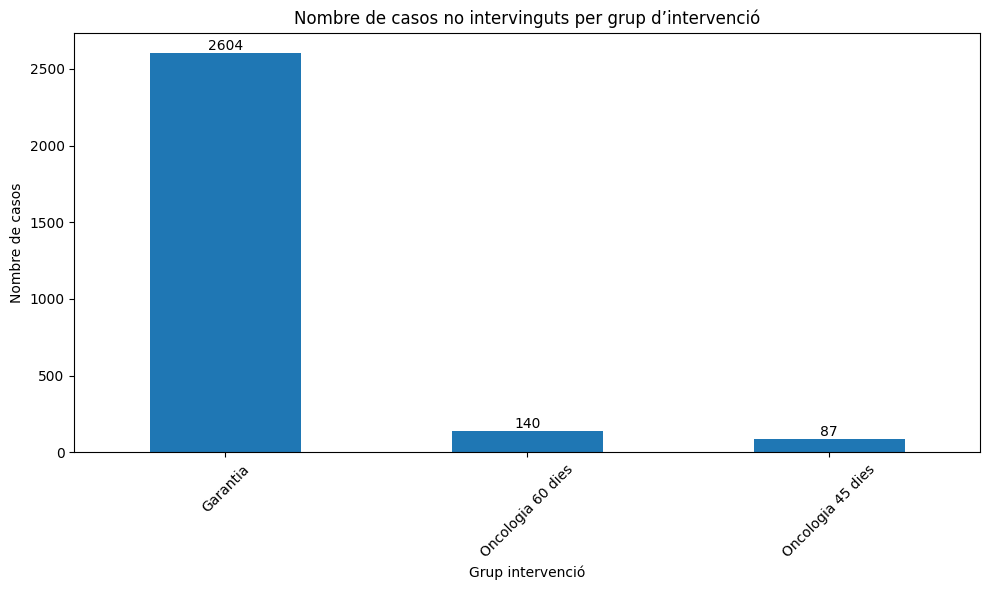

In [73]:
# Comptar valors
counts = df_no_operats['grup_intervencio'].value_counts()

# Crear gràfic de barres
ax = counts.plot(kind='bar', figsize=(10,6))

# Títols i etiquetes
plt.title('Nombre de casos no intervinguts per grup d’intervenció')
plt.xlabel('Grup intervenció')
plt.ylabel('Nombre de casos')

# Mostrar etiquetes de dades
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')

# Rotació etiquetes eix X
plt.xticks(rotation=45)

# Ajustar marges
plt.tight_layout()

# Mostrar gràfic
plt.show()

In [74]:
# Percentatge
(df_no_operats["Motiu de baixa"]
 .value_counts(normalize=True) * 100
).round(2)

,proportion
Motiu de baixa,
Trasllat a un altre centre,40.59
Sense especificar,33.42
Baixa voluntària del pacient,11.83
Baixa tècnica,5.55
Contraindicació mèdica,2.93
Èxitus SRD (no confirmat Reg defuncions),2.76
Pacient sol·licita o accepta demora,1.34
Pacient no localitzable,0.53
Pacient amb activ realitz. altre centre,0.46


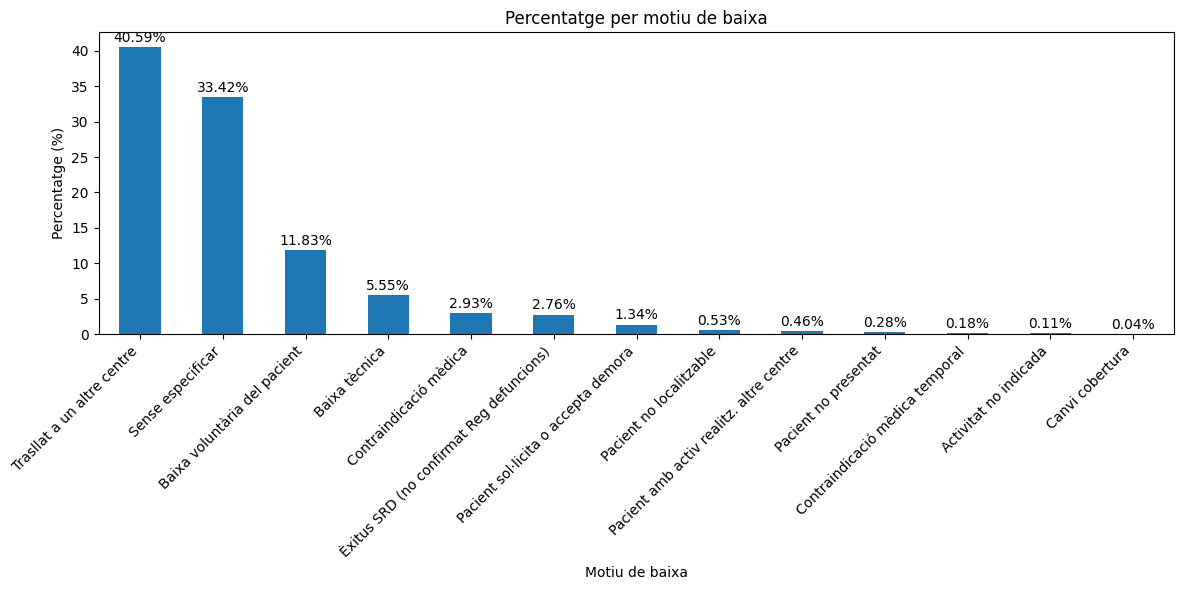

In [75]:
# Calcular percentatges
percentatges = (
    df_no_operats["Motiu de baixa"]
    .value_counts(normalize=True) * 100
).round(2)

# Crear gràfic de barres
ax = percentatges.plot(kind='bar', figsize=(12,6))

# Títols i etiquetes
plt.title('Percentatge per motiu de baixa')
plt.xlabel('Motiu de baixa')
plt.ylabel('Percentatge (%)')

# Mostrar etiquetes de dades
for i, v in enumerate(percentatges.values):
    ax.text(i, v + 0.3, f'{v}%', ha='center', va='bottom')

# Rotació etiquetes eix X
plt.xticks(rotation=45, ha='right')

# Ajustar marges
plt.tight_layout()

# Mostrar gràfic
plt.show()

In [76]:
# Per grup d'intervenció
(df_no_operats
 .groupby("grup_intervencio")["Motiu de baixa"]
 .value_counts(normalize=True) * 100
).round(2)

grup_intervencio   Motiu de baixa                          
Garantia           Trasllat a un altre centre                  41.90
                   Sense especificar                           34.06
                   Baixa voluntària del pacient                11.71
                   Baixa tècnica                                4.61
                   Èxitus SRD (no confirmat Reg defuncions)     2.69
                   Contraindicació mèdica                       2.00
                   Pacient sol·licita o accepta demora          1.38
                   Pacient no localitzable                      0.58
                   Pacient amb activ realitz. altre centre      0.46
                   Pacient no presentat                         0.31
                   Contraindicació mèdica temporal              0.19
                   Activitat no indicada                        0.08
                   Canvi cobertura                              0.04
Oncologia 45 dies  Sense especificar                           32.18
                   Baixa tècnica                               24.14
                   Contraindicació mèdica                      13.79
                   Baixa voluntària del pacient                12.64
                   Trasllat a un altre centre                  11.49
                   Pacient sol·licita o accepta demora          2.30
                   Èxitus SRD (no confirmat Reg defuncions)     2.30
                   Activitat no indicada                        1.15
Oncologia 60 dies  Trasllat a un altre centre                  34.29
                   Sense especificar                           22.14
                   Baixa voluntària del pacient                13.57
                   Contraindicació mèdica                      13.57
                   Baixa tècnica                               11.43
                   Èxitus SRD (no confirmat Reg defuncions)     4.29
                   Pacient amb activ realitz. altre centre      0.71
Name: proportion, dtype: float64

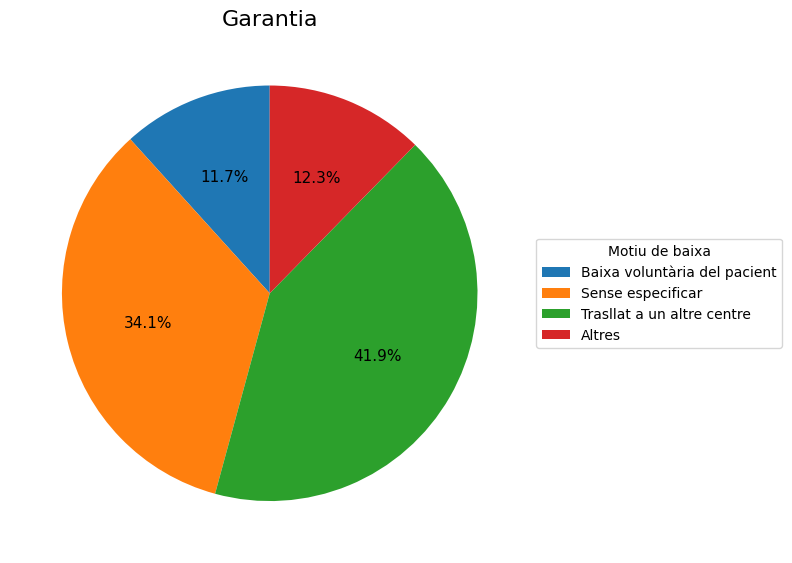

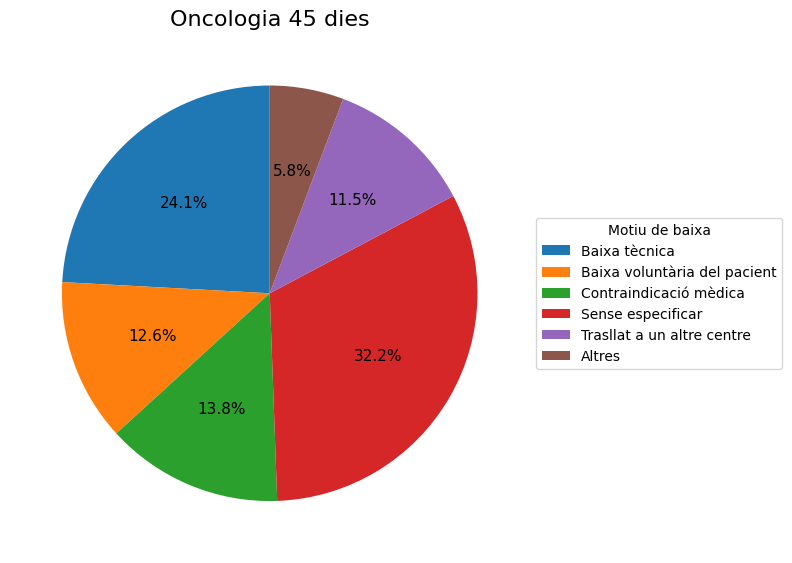

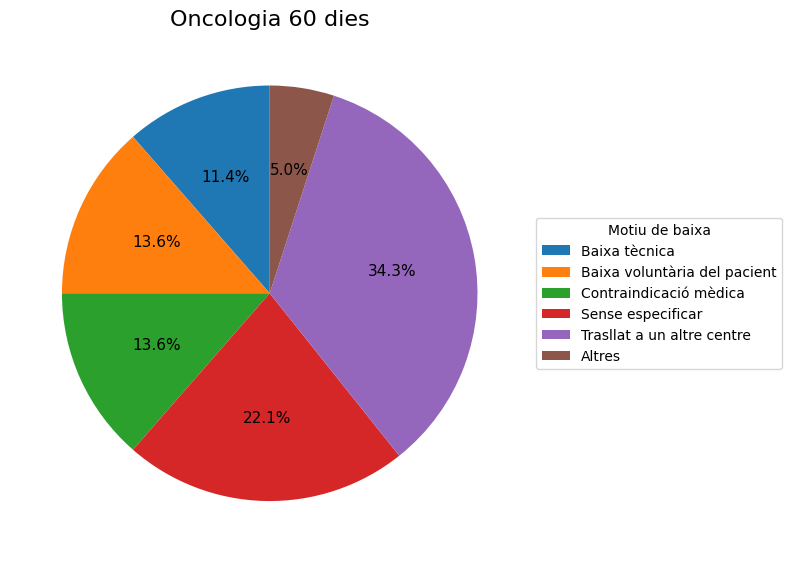

In [77]:
# Taula de percentatges
taula = (
    df_no_operats
    .groupby("grup_intervencio")["Motiu de baixa"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
)

# Llindar per agrupar categories petites
llindar = 5

# Crear un gràfic separat per cada grup
for grup, dades in taula.iterrows():

    # Eliminar zeros
    dades = dades[dades > 0]

    # Agrupar categories petites
    petites = dades[dades < llindar].sum()
    dades = dades[dades >= llindar]

    if petites > 0:
        dades["Altres"] = petites

    # Crear figura
    fig, ax = plt.subplots(figsize=(8,8))

    # Pie chart
    wedges, texts, autotexts = ax.pie(
        dades,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11}
    )

    # Títol
    ax.set_title(grup, fontsize=16)

    # Llegenda
    ax.legend(
        wedges,
        dades.index,
        title="Motiu de baixa",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10
    )

    # Ajust layout
    plt.tight_layout()

    # Mostrar gràfic
    plt.show()

In [78]:
# Per procediment
(df_no_operats
 .groupby(["grup_intervencio", "procediment"])["Motiu de baixa"]
 .value_counts(normalize=True) * 100
).round(2)

grup_intervencio   procediment                               Motiu de baixa                          
Garantia           Intervenció de cataracta                  Trasllat a un altre centre                   41.87
                                                             Sense especificar                            36.45
                                                             Baixa voluntària del pacient                 11.08
                                                             Baixa tècnica                                 4.45
                                                             Èxitus SRD (no confirmat Reg defuncions)      3.05
                                                             Contraindicació mèdica                        1.40
                                                             Pacient no localitzable                       0.63
                                                             Pacient no presentat                          0.39
                                                             Pacient amb activ realitz. altre centre       0.29
                                                             Pacient sol·licita o accepta demora           0.15
                                                             Activitat no indicada                         0.10
                                                             Contraindicació mèdica temporal               0.10
                                                             Canvi cobertura                               0.05
                   Pròtesi de genoll                         Sense especificar                            34.36
                                                             Trasllat a un altre centre                   26.12
                                                             Baixa voluntària del pacient                 18.56
                                                             Pacient sol·licita o accepta demora           8.25
                                                             Contraindicació mèdica                        5.15
                                                             Baixa tècnica                                 4.81
                                                             Contraindicació mèdica temporal               1.03
                                                             Pacient amb activ realitz. altre centre       1.03
                                                             Pacient no localitzable                       0.34
                                                             Èxitus SRD (no confirmat Reg defuncions)      0.34
                   Pròtesi de maluc                          Trasllat a un altre centre                   60.98
                                                             Sense especificar                            13.41
                                                             Baixa voluntària del pacient                  8.94
                                                             Baixa tècnica                                 5.69
                                                             Pacient sol·licita o accepta demora           3.66
                                                             Contraindicació mèdica                        3.25
                                                             Èxitus SRD (no confirmat Reg defuncions)      2.44
                                                             Pacient amb activ realitz. altre centre       1.22
                                                             Pacient no localitzable                       0.41
                   Reconstr. mamàries diferides primàries    Sense especificar                           100.00
Oncologia 45 dies  Neo malignes hemat. i del sist. limfàtic  Sense especificar                           100.00
                   Neo. maligna de matriu, ovaris i annexos  Contraindicació mèdica       

**Relació amb el temps d'espera**

In [79]:
df_no_operats["temps_total"] = (
    df_no_operats["data_baixa"] - df_no_operats["data_entrada"]
).dt.days

df_no_operats["dies_baixa_temp"] = (
    df_no_operats["data_fi_baixa_temporal"] - df_no_operats["data_inici_baixa_temporal"]
).dt.days

df_no_operats["dies_baixa_temp"] = df_no_operats["dies_baixa_temp"].fillna(0)

df_no_operats["temps_espera_real"] = (
    df_no_operats["temps_total"] - df_no_operats["dies_baixa_temp"]
)

# Eviatar valors negatius
df_no_operats["temps_espera_real"] = df_no_operats["temps_espera_real"].clip(lower=0)

/tmp/ipykernel_1175/1410442055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_operats["temps_total"] = (
/tmp/ipykernel_1175/1410442055.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_operats["dies_baixa_temp"] = (
/tmp/ipykernel_1175/1410442055.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

In [80]:
resum_proc = df_no_operats.groupby(
    ["procediment", "Motiu de baixa"]
)["temps_espera_real"].agg(
    mean="mean",
    median="median",
    count="count"
)

# Ordenar per procediment i N
resum_proc = resum_proc.sort_values(
    by=["procediment", "count"],
    ascending=[True, False]
)

# Arrodonir
resum_proc = resum_proc.round(2)

resum_proc

mean  \
procediment                              Motiu de baixa                                     
Intervenció de cataracta                 Trasllat a un altre centre                146.28   
                                         Baixa voluntària del pacient              160.30   
                                         Baixa tècnica                              72.78   
                                         Èxitus SRD (no confirmat Reg defuncions)  140.98   
                                         Contraindicació mèdica                    127.66   
                                         Pacient no localitzable                   215.92   
                                         Pacient no presentat                      187.62   
                                         Pacient amb activ realitz. altre centre   190.00   
                                         Sense especificar                         115.80   
                                         Pacient sol·licita o accepta demora       189.67   
                                         Activitat no indicada                     193.00   
                                         Contraindicació mèdica temporal           180.00   
                                         Canvi cobertura                           244.00   
Neo malignes hemat. i del sist. limfàtic Sense especificar                            NaN   
Neo. maligna de matriu, ovaris i annexos Contraindicació mèdica                      1.00   
Neo. maligna de ronyó i vies urinàries   Trasllat a un altre centre                 25.00   
                                         Contraindicació mèdica                     22.67   
                                         Pacient sol·licita o accepta demora        61.50   
                                         Baixa tècnica                              59.00   
                                         Baixa voluntària del pacient               50.00   
                                         Sense especificar                            NaN   
Neoplàsia maligna altres localitzacions  Trasllat a un altre centre                  9.50   
                                         Sense especificar                            NaN   
Neoplàsia maligna altres òrgans genitals Trasllat a un altre centre                 14.00   
Neoplàsia maligna de bufeta              Trasllat a un altre centre                 22.14   
                                         Contraindicació mèdica                     26.83   
                                         Baixa voluntària del pacient               25.24   
                                         Baixa tècnica                              15.27   
                                         Èxitus SRD (no confirmat Reg defuncions)   24.67   
                                         Pacient amb activ realitz. altre centre    20.00   
                                         Sense especificar                            NaN   
Neoplàsia maligna de còlon               Baixa tècnica                               5.00   
                                         Contraindicació mèdica                     36.50   
                                         Sense especificar                            NaN   
Neoplàsia maligna de mama                Baixa tècnica                              12.00   
                                         Contraindicació mèdica                     27.20   
                                         Baixa voluntària del pacient               14.50   
                                         Sense especificar                           0.00   
Neoplàsia maligna de pell                Baixa voluntària del pacient               48.25   
                                         Baixa tècnica                              26.50   
                                         Èxitus SRD (no confirmat Reg defuncions)   13.50   
                                         Activitat no indicada                      22

Baixa voluntària → temps alt? → pacients es cansen
Trasllat → temps alt? → problema de capacitat
Contraindicació → temps baix? → decisió clínica

# Anàlisi detallat del grup d'intervenció Garantia

Si te da tiempo, dentro del grupo de Garantía podría ser interesante abrir un pequeño subanálisis por procedimiento o especialidad, porque parece ser donde hay más volumen y también más variabilidad.

**Descripció del grup (volum)**

In [81]:
# Definim el subconjunt
df_garantia = df_episodi[df_episodi["grup_intervencio"] == "Garantia"].copy()

In [82]:
#Volum per procediment
df_garantia["procediment"].value_counts()

,count
procediment,
Intervenció de cataracta,6762
Pròtesi de genoll,883
Pròtesi de maluc,661
Reconstr. mamàries diferides primàries,3


**Anàlisi del flux (entades/sortides)**

In [83]:
# Definim data de sortida única
df_garantia["data_sortida"] = np.where(
    df_garantia["data_intervencio"].notna(),
    df_garantia["data_intervencio"],   # si s'ha operat → surt amb la intervenció
    df_garantia["data_baixa"]          # si no → surt amb la baixa
)

In [84]:
# Extreiem any d’entrada i sortida
df_garantia["any_entrada"] = df_garantia["data_entrada"].dt.year
df_garantia["any_sortida"] = pd.to_datetime(
    df_garantia["data_sortida"]
).dt.year

# Calculem les entrades i sortides anuals
entrades = df_garantia.groupby("any_entrada").size()
sortides = df_garantia.groupby("any_sortida").size()

# Construim taula de flux
df_flux_gar = pd.DataFrame({
    "Entrades": entrades,
    "Sortides": sortides
}).fillna(0).astype(int)

# Calcular saldo (backlog)
df_flux_gar["Saldo"] = df_flux_gar["Entrades"] - df_flux_gar["Sortides"]

# Filtrem anys d’estudi
df_flux_gar = df_flux_gar.loc[[2022, 2023, 2024, 2025]]

In [85]:
df_flux_gar

,Entrades,Sortides,Saldo
2022.0,1381,1281,100
2023.0,1568,1973,-405
2024.0,2116,1690,426
2025.0,2401,2491,-90


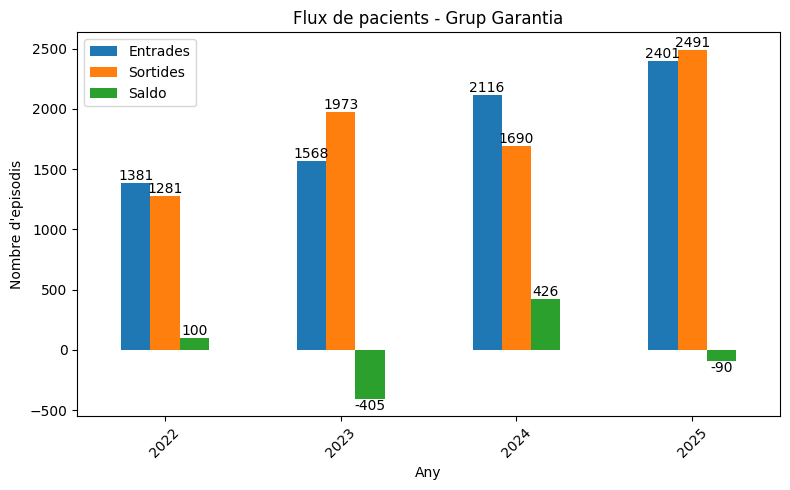

In [86]:
df_flux_gar.index = df_flux_gar.index.astype(int)
ax = df_flux_gar.plot(kind="bar", figsize=(8,5))

plt.title("Flux de pacients - Grup Garantia")
plt.xlabel("Any")
plt.ylabel("Nombre d'episodis")
plt.xticks(rotation=45)

# Afegir etiquetes
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

L'anàlisi del flux de pacients en el grup de Garantia mostra una evolució irregular en l'equilibri entre entrades i sortides al llarg del període analitzat.

L'any 2022 presenta un saldo lleugerament positiu (+100), indicant una certa acumulació inicial de pacients en llista d’espera. Aquesta tendència es reverteix el 2023, amb un saldo negatiu (-405), fet que suggereix una major capacitat resolutiva en relació amb la demanda durant aquest període.

Tanmateix, el 2024 es torna a observar un increment del backlog (+426), associat a un augment notable de les entrades que no és compensat per les sortides. Finalment, el 2025 mostra novament un saldo lleugerament negatiu (-90), indicant un cert reequilibri del sistema.

En conjunt, aquests resultats evidencien una manca d’estabilitat en la relació entre demanda i capacitat resolutiva, amb alternança entre períodes d’acumulació i de reducció de la llista d’espera. Aquesta variabilitat pot reflectir canvis en la pressió assistencial, en la capacitat quirúrgica o en la gestió del procés al llarg del temps.


INTERVENCIÓ DE CATARACTA
        Entrades  Sortides  Saldo
2022.0      1107    1007.0  100.0
2023.0      1238    1554.0 -316.0
2024.0      1783    1333.0  450.0
2025.0      2022    2120.0  -98.0


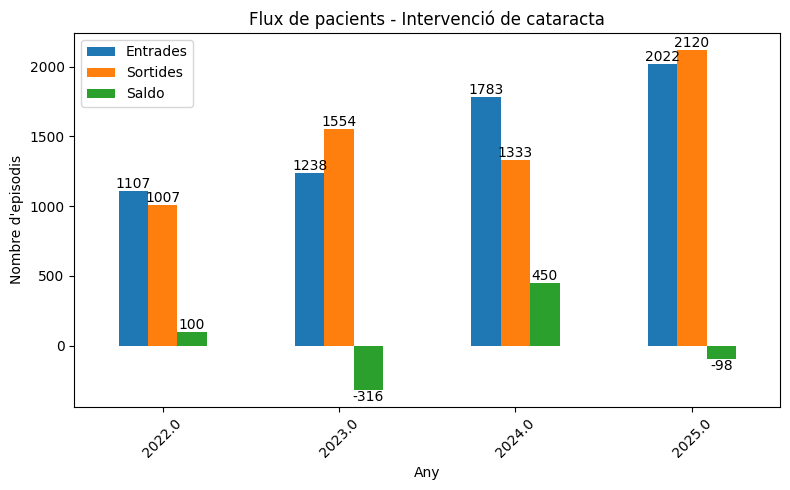


PRÒTESI DE GENOLL
        Entrades  Sortides  Saldo
2022.0       164     141.0   23.0
2023.0       169     245.0  -76.0
2024.0       181     201.0  -20.0
2025.0       224     198.0   26.0


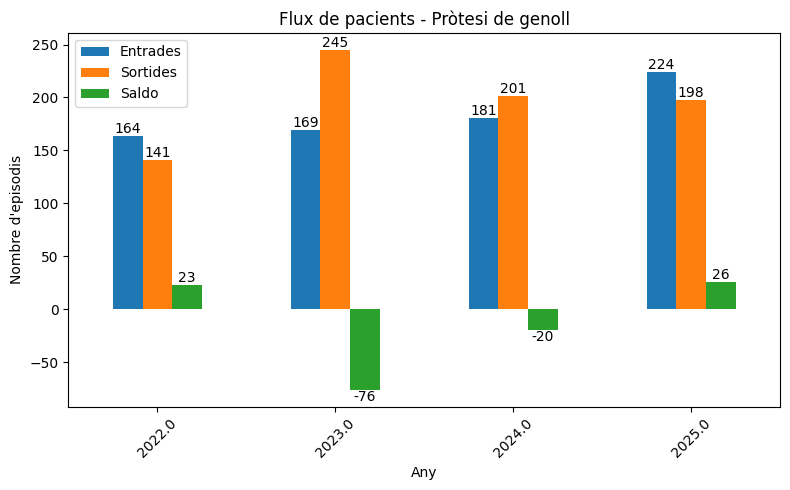


PRÒTESI DE MALUC
        Entrades  Sortides  Saldo
2022.0       110     133.0  -23.0
2023.0       159     174.0  -15.0
2024.0       151     155.0   -4.0
2025.0       155     172.0  -17.0


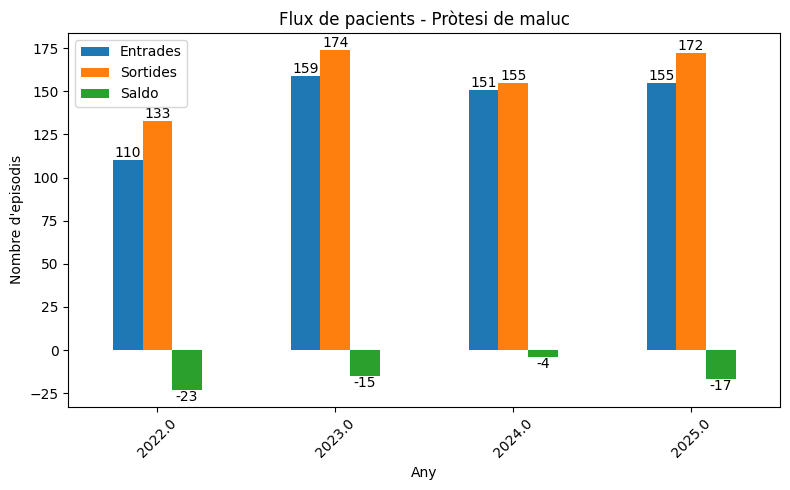

In [87]:
# FLUX PER PROCEDIMENT

procediments = [
    "Intervenció de cataracta",
    "Pròtesi de genoll",
    "Pròtesi de maluc"
]

for proc in procediments:

    print("\n" + "="*60)
    print(proc.upper())
    print("="*60)

    # Filtrar procediment
    df_proc = df_garantia[
        df_garantia["procediment"] == proc
    ].copy()

    # Entrades anuals
    entrades = (
        df_proc.groupby("any_entrada")
        .size()
    )

    # Sortides anuals
    sortides = (
        df_proc.groupby("any_sortida")
        .size()
    )

    # Taula flux
    df_flux = pd.DataFrame({
        "Entrades": entrades,
        "Sortides": sortides
    }).fillna(0)

    # Saldo
    df_flux["Saldo"] = (
        df_flux["Entrades"] -
        df_flux["Sortides"]
    )

    # Filtrar anys
    df_flux = df_flux.loc[2022:2025]

    print(df_flux)

    # Gràfic
    ax = df_flux.plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(f"Flux de pacients - {proc}")
    plt.xlabel("Any")
    plt.ylabel("Nombre d'episodis")

    plt.xticks(rotation=45)

    # Etiquetes
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f')

    plt.tight_layout()
    plt.show()

**Intervencions realitzades**

In [88]:
df_garantia["operat"] = df_garantia["Motiu de baixa"].isin([
    "Activitat realitzada",
    "Activitat realitzada d'urgència"
])

df_garantia[df_garantia["operat"]]["procediment"].value_counts()

,count
procediment,
Intervenció de cataracta,4696
Pròtesi de genoll,592
Pròtesi de maluc,415
Reconstr. mamàries diferides primàries,2


**Resolució (operats vs no operats)**

In [89]:
# % resolució vs NO resolució
(df_garantia["operat"].value_counts(normalize=True) * 100).round(2)

,proportion
operat,
True,68.66
False,31.34


L’anàlisi del grup de Garantia mostra que aproximadament el 68,7% dels pacients són intervinguts, mentre que un 31,3% no arriben a ser operats, evidenciant un volum rellevant de casos no resolts.

**Resolució per procediment**

In [90]:
# % resolució per procediment
(df_garantia
 .groupby("procediment")["operat"]
 .mean() * 100
).round(2)

,operat
procediment,
Intervenció de cataracta,69.45
Pròtesi de genoll,67.04
Pròtesi de maluc,62.78
Reconstr. mamàries diferides primàries,66.67


Per procediment, s’observa una certa variabilitat, amb percentatges de resolució inferiors en les pròtesis de maluc (62,8%) respecte a la cataracta (69,5%), suggerint una major dificultat resolutiva en procediments més complexos.

**Compliment (només operats)**


In [91]:
# % compliment
df_operats_gar = df_garantia[df_garantia["data_intervencio"].notna()].copy()

# Calcular % compliment
compliment = (df_operats_gar["compliment"].mean() * 100).round(2)

print(f"Compliment Garantia: {compliment}%")

Compliment Garantia: 50.43%


**Compliment (només operats) per procediment**


In [92]:
# % compliment per grup
compliment_grup = (
    df_operats_gar
    .groupby("procediment")["compliment"]
    .mean()
    .mul(100)
    .round(2)
)

print(compliment_grup)

procediment
Intervenció de cataracta                  52.587859
Pròtesi de genoll                         25.932203
Pròtesi de maluc                          62.362637
Reconstr. mamàries diferides primàries         50.0
Name: compliment, dtype: object


In [93]:
# Volum per procediment pacients NO operats
df_garantia[
    df_garantia["operat"] == False
]["procediment"].value_counts()

,count
procediment,
Intervenció de cataracta,2066
Pròtesi de genoll,291
Pròtesi de maluc,246
Reconstr. mamàries diferides primàries,1


**Anàlisi de pacients no operats**

In [94]:
# 1. Definim variable operat (millor amb data_intervencio)
df_garantia["operat"] = df_garantia["data_intervencio"].notna()

# 2. Subconjunt de NO operats
df_no_operats = df_garantia[~df_garantia["operat"]].copy()

# 3. Volum total
n_no_operats = df_no_operats.shape[0]
print(f"Nombre de pacients no operats: {n_no_operats}")

# 4. Percentatge respecte total
pct_no_operats = (n_no_operats / df_garantia.shape[0]) * 100
print(f"% no operats: {pct_no_operats:.2f}%")

# 5. Distribució de motius de baixa (%)
motiu_dist = (
    df_no_operats["Motiu de baixa"]
    .value_counts(normalize=True) * 100
).round(2)

print(motiu_dist)

Nombre de pacients no operats: 2658
% no operats: 31.99%
Motiu de baixa
Trasllat a un altre centre                  41.05
Sense especificar                           33.37
Baixa voluntària del pacient                11.47
Baixa tècnica                                4.51
Èxitus SRD (no confirmat Reg defuncions)     2.63
Activitat realitzada d'urgència              2.03
Contraindicació mèdica                       1.96
Pacient sol·licita o accepta demora          1.35
Pacient no localitzable                      0.56
Pacient amb activ realitz. altre centre      0.45
Pacient no presentat                         0.30
Contraindicació mèdica temporal              0.19
Activitat no indicada                        0.08
Canvi cobertura                              0.04
Name: proportion, dtype: float64


Els resultats mostren que aproximadament un 32% dels pacients del grup de Garantia no arriben a ser intervinguts, evidenciant un volum rellevant d’episodis no resolts.

Pel que fa als motius de sortida, el principal és el trasllat a un altre centre (41,05%), fet que suggereix possibles limitacions de capacitat o derivacions a altres proveïdors per gestionar la demanda. En segon lloc, destaca un percentatge elevat de casos sense especificar (33,37%), la qual cosa indica una limitació important en la qualitat del registre de dades.

Altres motius rellevants inclouen la baixa voluntària del pacient (11,47%), que podria estar relacionada amb temps d’espera elevats, i en menor mesura factors clínics o organitzatius com la baixa tècnica o la contraindicació mèdica.

In [95]:
# Per procediment
procediments = df_garantia["procediment"].unique()

for proc in procediments:

    print("\n" + "="*60)
    print(proc.upper())
    print("="*60)

    # Filtrar procediment
    df_proc = df_garantia[
        df_garantia["procediment"] == proc
    ].copy()

    # Variable operat
    df_proc["operat"] = (
        df_proc["data_intervencio"].notna()
    )

    # Subconjunt NO operats
    df_no_operats_proc = df_proc[
        ~df_proc["operat"]
    ].copy()

    # Volum
    n_no_operats = df_no_operats_proc.shape[0]

    # Percentatge
    pct_no_operats = (
        n_no_operats /
        df_proc.shape[0]
    ) * 100

    print(f"Nombre no operats: {n_no_operats}")
    print(f"% no operats: {pct_no_operats:.2f}%")

    # Distribució motius baixa
    motiu_dist = (
        df_no_operats_proc["Motiu de baixa"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nDistribució motius de baixa:")
    print(motiu_dist)


PRÒTESI DE MALUC
Nombre no operats: 297
% no operats: 44.93%

Distribució motius de baixa:
Motiu de baixa
Trasllat a un altre centre                  50.51
Activitat realitzada d'urgència             17.17
Sense especificar                           11.11
Baixa voluntària del pacient                 7.41
Baixa tècnica                                4.71
Pacient sol·licita o accepta demora          3.03
Contraindicació mèdica                       2.69
Èxitus SRD (no confirmat Reg defuncions)     2.02
Pacient amb activ realitz. altre centre      1.01
Pacient no localitzable                      0.34
Name: proportion, dtype: float64

INTERVENCIÓ DE CATARACTA
Nombre no operats: 2067
% no operats: 30.57%

Distribució motius de baixa:
Motiu de baixa
Trasllat a un altre centre                  41.85
Sense especificar                           36.43
Baixa voluntària del pacient                11.08
Baixa tècnica                                4.45
Èxitus SRD (no confirmat Reg defuncions)    

**Relació temps – motiu de sortida**

In [96]:
# 1. Temps fins sortida (entrada → baixa)
df_no_operats["temps_sortida"] = (
    df_no_operats["data_baixa"] - df_no_operats["data_entrada"]
).dt.days

# 2. Evitar valors negatius o nuls
df_no_operats["temps_sortida"] = df_no_operats["temps_sortida"].clip(lower=0)

# 3. Resum per motiu (mean, median, count)
resum_temps = df_no_operats.groupby("Motiu de baixa")["temps_sortida"].agg(
    mean="mean",
    median="median",
    count="count"
).round(2)

# 4. Ordenar per volum
resum_temps = resum_temps.sort_values(by="count", ascending=False)

print(resum_temps)

                                            mean  median  count
Motiu de baixa                                                 
Trasllat a un altre centre                142.10   123.0   1091
Baixa voluntària del pacient              215.41   189.0    305
Baixa tècnica                              81.80    18.0    120
Èxitus SRD (no confirmat Reg defuncions)  155.73   148.0     70
Activitat realitzada d'urgència            11.54     1.0     54
Contraindicació mèdica                    210.52   176.5     52
Pacient sol·licita o accepta demora       213.06   207.0     36
Pacient no localitzable                   263.87   248.0     15
Sense especificar                         160.08   161.0     13
Pacient amb activ realitz. altre centre   216.50   198.0     12
Pacient no presentat                      222.25   204.0      8
Contraindicació mèdica temporal           232.80   205.0      5
Activitat no indicada                     226.50   226.5      2
Canvi cobertura                         

L’anàlisi del temps fins a la sortida en els pacients no operats mostra diferències rellevants segons el motiu de baixa.

Els trasllats a un altre centre, que són el motiu més freqüent, presenten un temps d’espera elevat (mitjana de 142 dies), fet que reforça la hipòtesi que aquests casos podrien estar relacionats amb problemes de capacitat o derivacions després d’un període prolongat en llista d’espera.

Destaca especialment la baixa voluntària del pacient, amb temps molt elevats (mitjana de 215 dies), així com els casos en què el pacient accepta demora o no es pot localitzar, també associats a esperes prolongades. Aquest patró suggereix una relació clara entre temps d’espera elevats i abandonament del procés.

En canvi, alguns motius presenten temps molt reduïts, com l’activitat realitzada d’urgència (mitjana de 11 dies), indicant una resolució ràpida per necessitat clínica.

Finalment, els casos de contraindicació mèdica també mostren temps elevats, la qual cosa pot indicar que la decisió clínica es produeix després d’un període prolongat en llista d’espera.

En conjunt, els resultats evidencien que els temps d’espera llargs estan associats principalment a sortides no desitjades del procés, especialment per abandonament del pacient o derivació a altres centres.

In [97]:
# RELACIÓ TEMPS - MOTIU DE SORTIDA PER PROCEDIMENT

for proc in procediments:

    print("\n" + "="*60)
    print(proc.upper())
    print("="*60)

    # Filtrar procediment
    df_proc = df_no_operats[
        df_no_operats["procediment"] == proc
    ].copy()

    # Temps fins sortida
    df_proc["temps_sortida"] = (
        df_proc["data_baixa"] -
        df_proc["data_entrada"]
    ).dt.days

    # Evitar negatius
    df_proc["temps_sortida"] = (
        df_proc["temps_sortida"]
        .clip(lower=0)
    )

    # Resum per motiu
    resum_temps = (
        df_proc
        .groupby("Motiu de baixa")["temps_sortida"]
        .agg(
            mean="mean",
            median="median",
            count="count"
        )
        .round(2)
    )

    # Ordenar per volum
    resum_temps = resum_temps.sort_values(
        by="count",
        ascending=False
    )

    print(resum_temps)


PRÒTESI DE MALUC
                                            mean  median  count
Motiu de baixa                                                 
Trasllat a un altre centre                124.29    89.0    150
Activitat realitzada d'urgència             2.80     1.0     51
Baixa voluntària del pacient              317.50   208.5     22
Baixa tècnica                             174.50    88.5     14
Pacient sol·licita o accepta demora       204.67   209.0      9
Contraindicació mèdica                    406.62   287.5      8
Sense especificar                         164.17   165.0      6
Èxitus SRD (no confirmat Reg defuncions)  182.00   114.5      6
Pacient amb activ realitz. altre centre   249.67   118.0      3
Pacient no localitzable                   478.00   478.0      1

INTERVENCIÓ DE CATARACTA
                                            mean  median  count
Motiu de baixa                                                 
Trasllat a un altre centre                147.24   133.0    

# Anàlisi ètic


In [103]:
df_analisi = df_episodi.copy()

TEMPS D'ESPERA

In [104]:
# Sexe
df_sexe = (
    df_analisi
    .groupby("sexe")["temps_total_espera"]
    .mean()
    .reset_index()
)

print(df_sexe)

   sexe  temps_total_espera
0     0          149.074783
1     1          150.599112


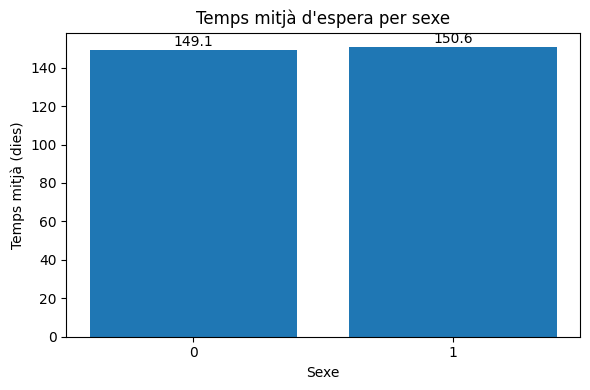

In [105]:
plt.figure(figsize=(6,4))

plt.bar(
    df_sexe["sexe"].astype(str),
    df_sexe["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per sexe")
plt.xlabel("Sexe")
plt.ylabel("Temps mitjà (dies)")

for i, v in enumerate(df_sexe["temps_total_espera"]):
    plt.text(i, v + 2, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

In [106]:
# Grup d'edat
df_analisi["grup_edat"] = pd.cut(
    df_analisi["edat"],
    bins=[0, 40, 60, 80, 120],
    labels=["<40", "40-60", "60-80", ">80"]
)

In [107]:
df_edat = (
    df_analisi
    .groupby("grup_edat")["temps_total_espera"]
    .mean()
    .reset_index()
)

/tmp/ipykernel_1175/2195283554.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("grup_edat")["temps_total_espera"]


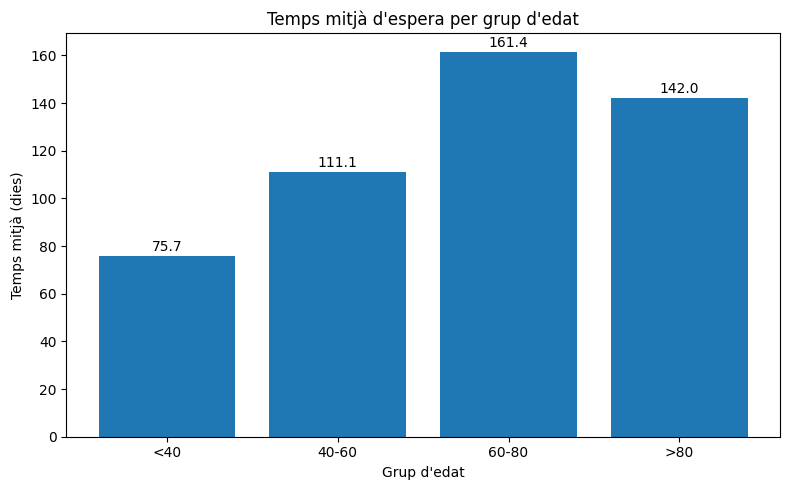

In [108]:
plt.figure(figsize=(8,5))

plt.bar(
    df_edat["grup_edat"].astype(str),
    df_edat["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per grup d'edat")
plt.xlabel("Grup d'edat")
plt.ylabel("Temps mitjà (dies)")

for i, v in enumerate(df_edat["temps_total_espera"]):
    plt.text(i, v + 2, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

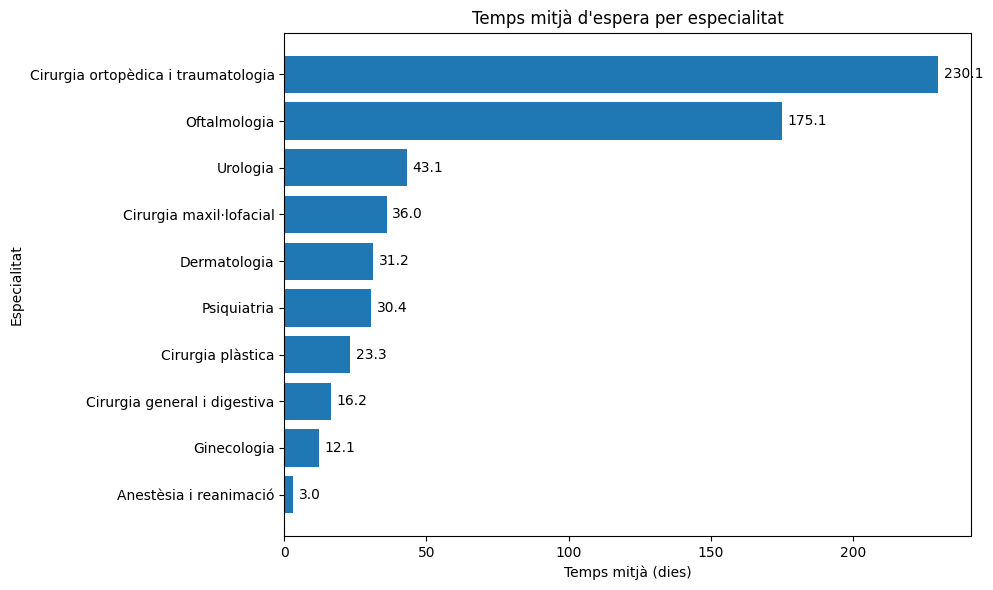

In [110]:
# Especialitat
df_especialitat = (
    df_analisi
    .groupby("especialitat")["temps_total_espera"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
plt.figure(figsize=(10,6))

plt.barh(
    df_especialitat["especialitat"],
    df_especialitat["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per especialitat")
plt.xlabel("Temps mitjà (dies)")
plt.ylabel("Especialitat")

for i, v in enumerate(df_especialitat["temps_total_espera"]):
    plt.text(v + 2, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

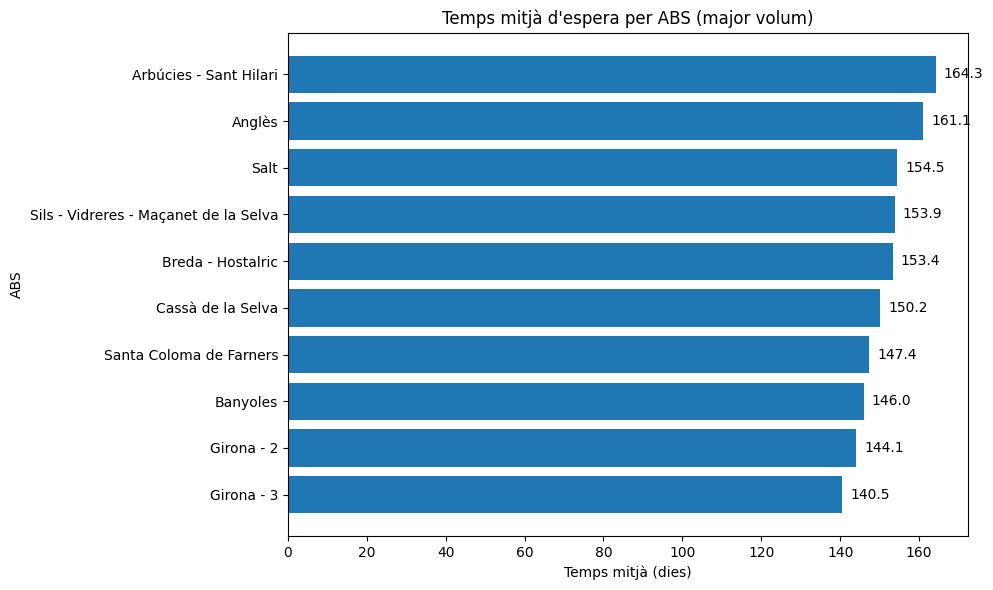

In [116]:
# ABS

# TOP 10 ABS amb més volum
top_abs = (
    df_analisi["ABS"]
    .value_counts()
    .head(10)
    .index
)

# Filtrar només aquestes ABS
df_abs = (
    df_analisi[
        df_analisi["ABS"].isin(top_abs)
    ]
    .groupby("ABS")["temps_total_espera"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

# Gràfic
plt.figure(figsize=(10,6))

plt.barh(
    df_abs["ABS"],
    df_abs["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per ABS (major volum)")
plt.xlabel("Temps mitjà (dies)")
plt.ylabel("ABS")

# Etiquetes
for i, v in enumerate(df_abs["temps_total_espera"]):
    plt.text(v + 2, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

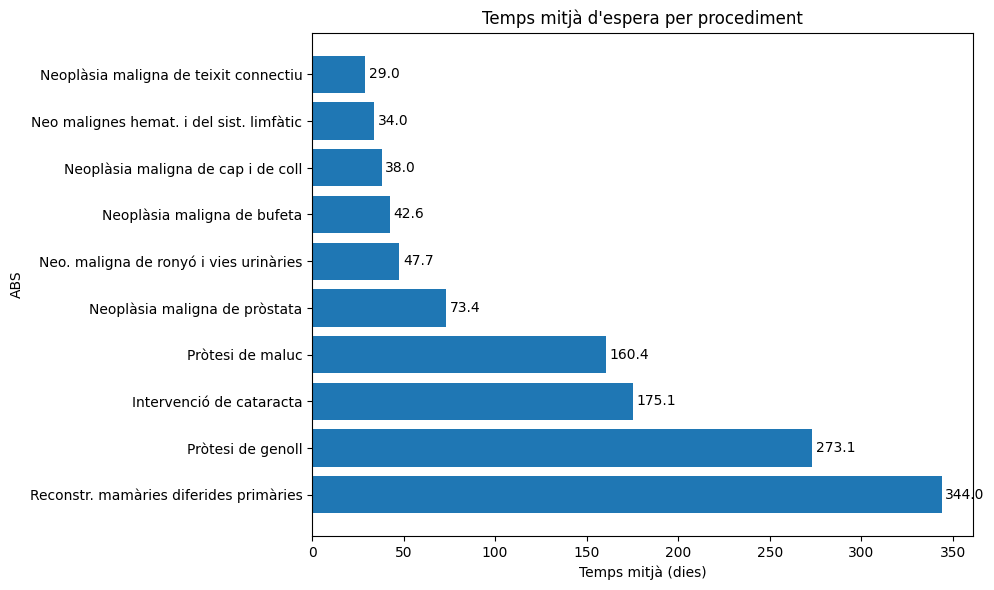

In [114]:
df_proc = (
    df_analisi
    .groupby("procediment")["temps_total_espera"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

plt.barh(
    df_proc["procediment"],
    df_proc["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per procediment")
plt.xlabel("Temps mitjà (dies)")
plt.ylabel("ABS")

for i, v in enumerate(df_proc["temps_total_espera"]):
    plt.text(v + 2, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

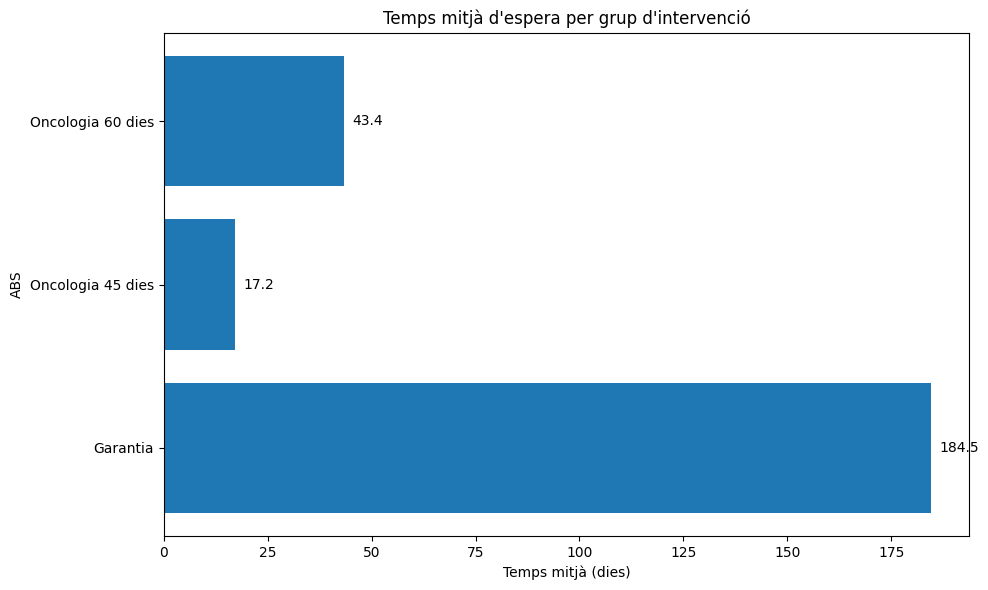

In [115]:
df_grup = (
    df_analisi
    .groupby("grup_intervencio")["temps_total_espera"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

plt.barh(
    df_grup["grup_intervencio"],
    df_grup["temps_total_espera"]
)

plt.title("Temps mitjà d'espera per grup d'intervenció")
plt.xlabel("Temps mitjà (dies)")
plt.ylabel("ABS")

for i, v in enumerate(df_grup["temps_total_espera"]):
    plt.text(v + 2, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()


COMPLIMENT

In [123]:
resultat_sexe = (
    df_analisi
    .groupby("sexe")["compliment"]
    .mean() * 100
)

print(resultat_sexe.map(lambda x: f"{x:.2f}%"))

sexe
0    59.04%
1    59.18%
Name: compliment, dtype: object


grup_edat
<40      80.46%
40-60    72.78%
60-80    55.63%
>80      60.20%
Name: compliment, dtype: object


/tmp/ipykernel_1175/942117914.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("grup_edat")["compliment"]


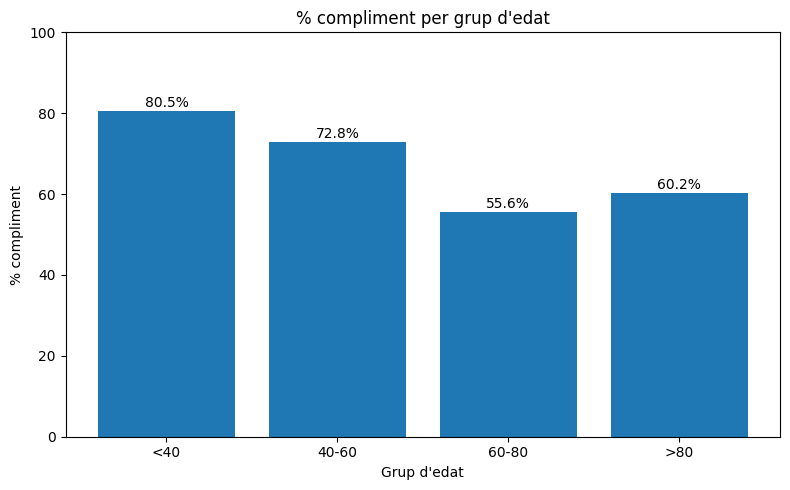

In [139]:
df_analisi["grup_edat"] = pd.cut(
    df_analisi["edat"],
    bins=[0,40,60,80,120],
    labels=["<40","40-60","60-80",">80"]
)

resultat_edat = (
    df_analisi
    .groupby("grup_edat")["compliment"]
    .mean() * 100
)

print(resultat_edat.map(lambda x: f"{x:.2f}%"))

df_plot = resultat_edat.reset_index(name="% compliment")

plt.figure(figsize=(8,5))

plt.bar(
    df_plot["grup_edat"].astype(str),
    df_plot["% compliment"]
)

plt.title("% compliment per grup d'edat")
plt.xlabel("Grup d'edat")
plt.ylabel("% compliment")

for i, v in enumerate(df_plot["% compliment"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.ylim(0,100)

plt.tight_layout()
plt.show()

especialitat
Cirurgia ortopèdica i traumatologia     39.83%
Oftalmologia                            52.59%
Dermatologia                            74.29%
Urologia                                83.54%
Cirurgia plàstica                       95.05%
Cirurgia general i digestiva            96.00%
Ginecologia                             99.18%
Anestèsia i reanimació                 100.00%
Cirurgia maxil·lofacial                100.00%
Psiquiatria                            100.00%
Name: compliment, dtype: object


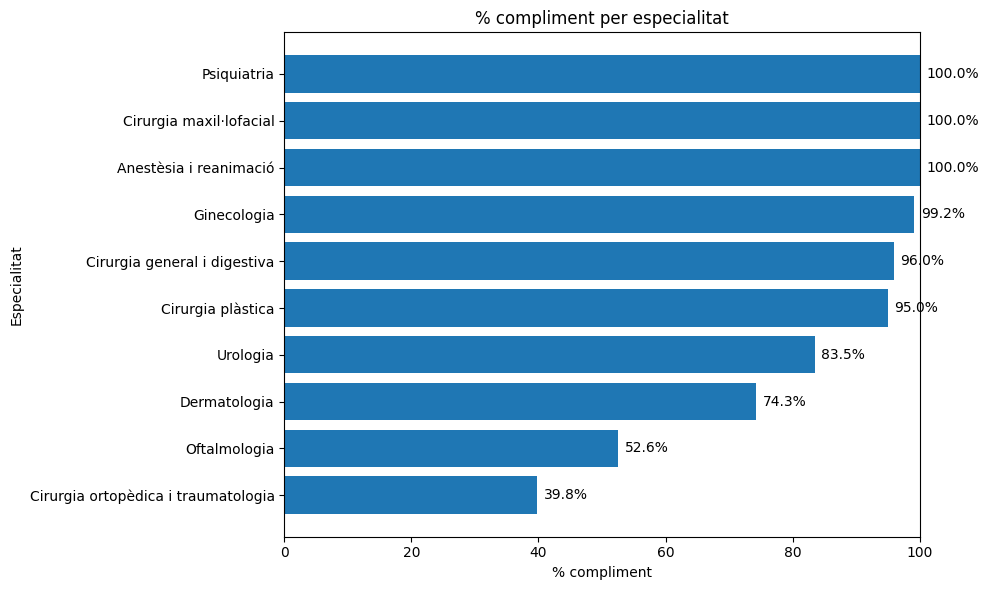

In [138]:
resultat_esp = (
    (
        df_analisi
        .groupby("especialitat")["compliment"]
        .mean() * 100
    )
    .sort_values()
)

print(resultat_esp.map(lambda x: f"{x:.2f}%"))

df_plot = resultat_esp.reset_index(name="% compliment")

plt.figure(figsize=(10,6))

plt.barh(
    df_plot["especialitat"],
    df_plot["% compliment"]
)

plt.title("% compliment per especialitat")
plt.xlabel("% compliment")
plt.ylabel("Especialitat")

for i, v in enumerate(df_plot["% compliment"]):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.xlim(0,100)

plt.tight_layout()
plt.show()

procediment
Pròtesi de genoll                          25.93%
Neoplàsia maligna de pròstata              33.33%
Neo. maligna de ronyó i vies urinàries     47.50%
Intervenció de cataracta                   52.59%
Pròtesi de maluc                           62.36%
Neoplàsia maligna altres localitzacions    82.35%
Neoplàsia maligna de pell                  84.80%
Neoplàsia maligna de bufeta                86.68%
Neoplàsia maligna de còlon                 98.80%
Neoplàsia maligna de mama                  99.16%
Name: compliment, dtype: object


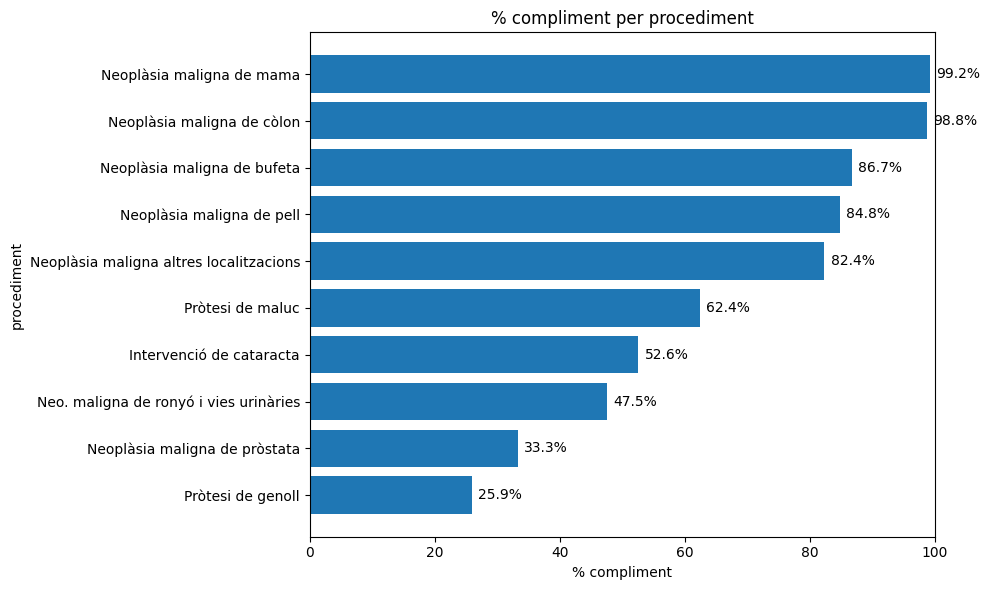

In [137]:
top_proc = (
    df_analisi["procediment"]
    .value_counts()
    .head(10)
    .index
)

resultat_proc = (
    (
    df_analisi[
        df_analisi["procediment"].isin(top_proc)
    ]
    .groupby("procediment")["compliment"]
    .mean() * 100
    )
    .sort_values()
)

print(resultat_proc.map(lambda x: f"{x:.2f}%"))

df_plot = resultat_proc.reset_index(name="% compliment")

plt.figure(figsize=(10,6))

plt.barh(
    df_plot["procediment"],
    df_plot["% compliment"]
)

plt.title("% compliment per procediment")
plt.xlabel("% compliment")
plt.ylabel("procediment")

for i, v in enumerate(df_plot["% compliment"]):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.xlim(0,100)

plt.tight_layout()
plt.show()

In [131]:
resultat_grup = (
    df_analisi
    .groupby("grup_intervencio")["compliment"]
    .mean() * 100
)

print(resultat_grup.map(lambda x: f"{x:.2f}%"))

grup_intervencio
Garantia             50.43%
Oncologia 45 dies    92.93%
Oncologia 60 dies    85.24%
Name: compliment, dtype: object


ABS
Arbúcies - Sant Hilari                   54.09%
Banyoles                                 55.37%
Sils - Vidreres - Maçanet de la Selva    57.11%
Anglès                                   57.54%
Salt                                     58.62%
Girona - 3                               59.19%
Girona - 2                               59.89%
Santa Coloma de Farners                  61.19%
Breda - Hostalric                        61.68%
Cassà de la Selva                        61.92%
Name: compliment, dtype: object


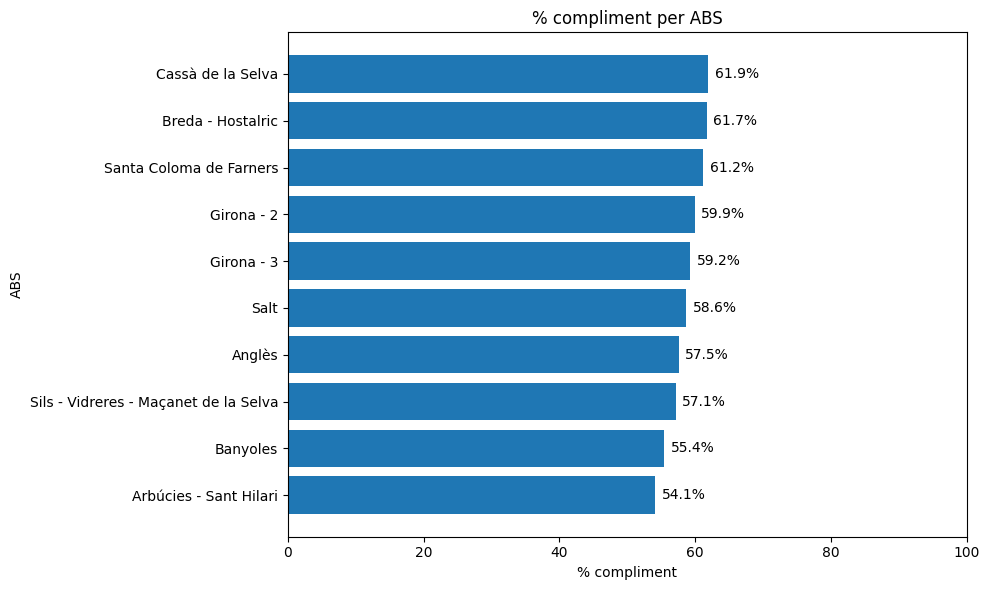

In [136]:
top_abs = (
    df_analisi["ABS"]
    .value_counts()
    .head(10)
    .index
)

resultat_abs = (
    (
    df_analisi[
        df_analisi["ABS"].isin(top_abs)
    ]
    .groupby("ABS")["compliment"]
    .mean() * 100
    )
    .sort_values()
)

print(resultat_abs.map(lambda x: f"{x:.2f}%"))

df_plot = resultat_abs.reset_index(name="% compliment")

plt.figure(figsize=(10,6))

plt.barh(
    df_plot["ABS"],
    df_plot["% compliment"]
)

plt.title("% compliment per ABS")
plt.xlabel("% compliment")
plt.ylabel("ABS")

for i, v in enumerate(df_plot["% compliment"]):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.xlim(0,100)

plt.tight_layout()
plt.show()